### Imports

In [ ]:
from datetime import datetime
import matplotlib.pyplot as plt
import joblib
from numpy import random
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

### Download Dataset

In [ ]:
# Initial dataset setting code was written collaboratively between all group members
raw_dataset_url = "https://raw.githubusercontent.com/Geo-y20/Telco-Customer-Churn-/refs/heads/main/Telco%20Customer%20Churn.csv"
df = pd.read_csv(raw_dataset_url)

### Initial Examination of Data

In [ ]:
# Seyi originally wrote this code and was reviewed by Zachary, Dharmik, and Ceasar
df.head()
df_work = df.copy()
# Get information on working dataset
df_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# calculate total null values
df_work.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Initial Cleaning of Data

In [ ]:
# This part originally written by Seyi, but needed adjustment for splitting
# Zachary edited

# Drop duplicate rows based on customerID
duplicate_rows = df_work[df_work.duplicated(subset="customerID", keep="first")]
df_work = df_work.drop_duplicates(subset="customerID", keep="first")

print("Duplicate rows:", duplicate_rows)

# if duplicates exist, drop them
if len(duplicate_rows) > 0:
    df_work = df_work.drop_duplicates()
    print("Duplicates removed. New shape:", df_work.shape)
else:
    print("No duplicate rows found.")


# SeniorCitizen is pre-encoded.  Adjust for this, used later after split
pre_encoded_category = "SeniorCitizen"

# There are some blank values (including some that are just a space) in total
# charges, which is for some reason stored as a string.
# Find these as these are not N/A values and replace them

# Strip whitespace
df_work["TotalCharges"] = df_work["TotalCharges"].str.strip()

# Convert strings that are empty or contain non-numeric characters to NaN
df_work["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop rows that could not be converted (NaN)
# And also drop any rows that have missing data outside of TotalCharges
dropped_rows = df_work[df_work.isna().any(axis=1)]
print(dropped_rows)
df_work = df_work.dropna()


# TotalCharges is stored as a string. Let's fix this
# We checked for null values and examined the data astype should be fine
# Additionally, we definitely want an error if we have bad data in this
# column
df_work["TotalCharges"] = pd.to_numeric(
    df_work["TotalCharges"], errors="raise").astype("float64")

df_work.describe()
df_work.info()

Duplicate rows: Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]
No duplicate rows found.
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes 

### Splitting out Training, Validation, and Testing data

In [ ]:
# Zachary wrote this code to split out training, test, and verification data

# Separate training and test data
target = 'Churn'

# x has all columns EXCEPT Churn (so ML does not cheat!!)
# Additionally, customerID should have no effect on the data as it's just an ID
# Remove non-features as well before splitting
x = df_work.drop(columns=[target, 'customerID'])
# y has only Churn
y = df_work[target]

# Now let's split the data into training, test, and verification
# Since this is a Classification problem, we will need to stratify the data
# and it should be stratified based on the target data.
# Through research, we found that the ratio of training, test, and verification
# should be 70-15-15

# Now let's split the data into training, test, and verification
# Since this is a Classification problem, we will need to stratify the data
# and it should be stratified based on the target data.
# Through research, we found that the ratio of training, test, and verification
# should be 70-15-15

# First we split it out to get the first 70% and set it as the training data
x_training, x_to_split, y_training, y_to_split = train_test_split(
    x, y,
    test_size=0.3,
    random_state=123,
    stratify=y,
    shuffle=True
)

# Now split x_to_split and y_to_split (which is the remaining 30%) in half and
# set the test_size as .5 to give test and validation 15% each of the original
# set
x_test, x_validation, y_test, y_validation = train_test_split(
    x_to_split, y_to_split,
    test_size=0.5,
    random_state=123,
    stratify=y_to_split,
    shuffle=True
)

### Determine Numeric and Categorical Features

In [ ]:
# Now that everything is split, separate into numeric and catagorical.
# And also, remove SeniorCitizen from numeric and put into categorical.
# Actually moving it here makes less headaches later.
numerical_columns = x_training.select_dtypes(
    include=["int64", "float64"]).columns.difference([pre_encoded_category])
categorical_columns = list(x_training.select_dtypes(
    include=["object", "category", "bool"]).columns) + [pre_encoded_category]

print(f"Numeric columns: {numerical_columns}")
print(f"Categorical columns: {categorical_columns}")

Numeric columns: Index(['MonthlyCharges', 'TotalCharges', 'tenure'], dtype='object')
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']


### Analysis of features

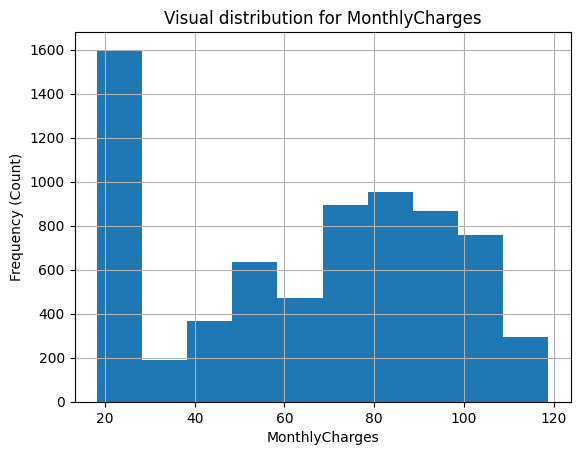

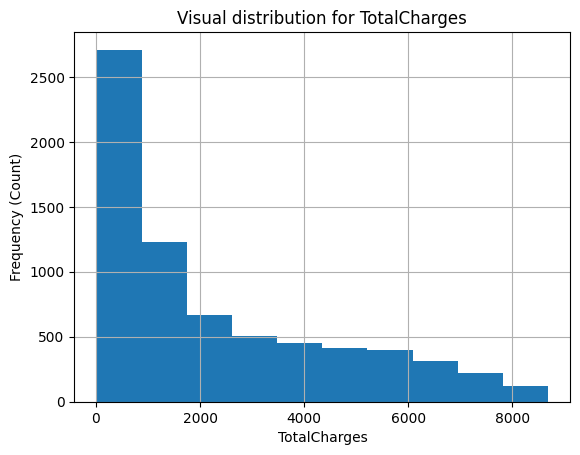

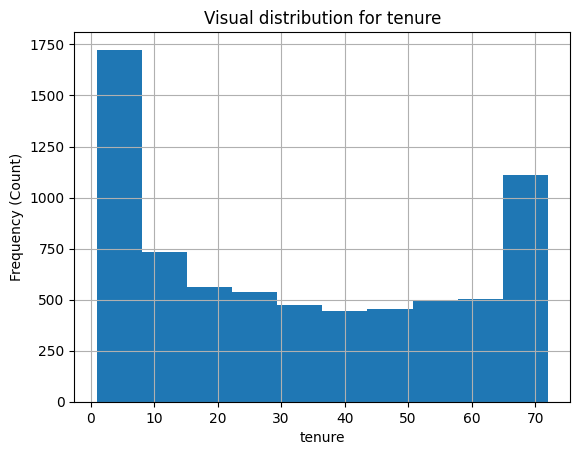

In [ ]:
# Numerical Analysis
# Definitely non linear data from looking at graph shape.

import matplotlib.pyplot as plt

for col in numerical_columns:
    plt.title(f'Visual distribution for {col}')
    ax = df_work[col].hist()
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency (Count)')
    plt.show()
    print(" ")

In [ ]:
# Categorical Data

for col in categorical_columns:
    print(df_work[col].value_counts(normalize=True))

# Features to drop
# Phone Service can be derived from MultipleLines

gender
Male      0.504693
Female    0.495307
Name: proportion, dtype: float64
Partner
No     0.517491
Yes    0.482509
Name: proportion, dtype: float64
Dependents
No     0.701507
Yes    0.298493
Name: proportion, dtype: float64
PhoneService
Yes    0.903299
No     0.096701
Name: proportion, dtype: float64
MultipleLines
No                  0.481371
Yes                 0.421928
No phone service    0.096701
Name: proportion, dtype: float64
InternetService
Fiber optic    0.440273
DSL            0.343572
No             0.216155
Name: proportion, dtype: float64
OnlineSecurity
No                     0.497298
Yes                    0.286547
No internet service    0.216155
Name: proportion, dtype: float64
OnlineBackup
No                     0.438993
Yes                    0.344852
No internet service    0.216155
Name: proportion, dtype: float64
DeviceProtection
No                     0.439989
Yes                    0.343857
No internet service    0.216155
Name: proportion, dtype: float64
TechSupp

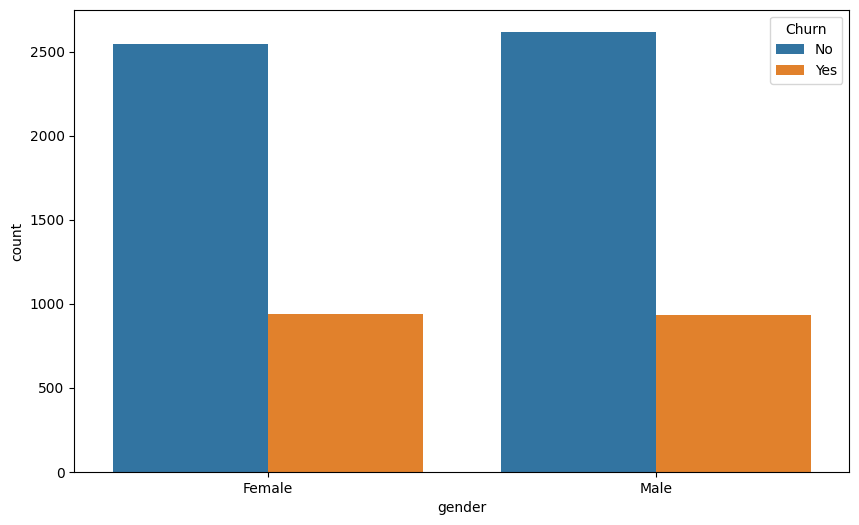

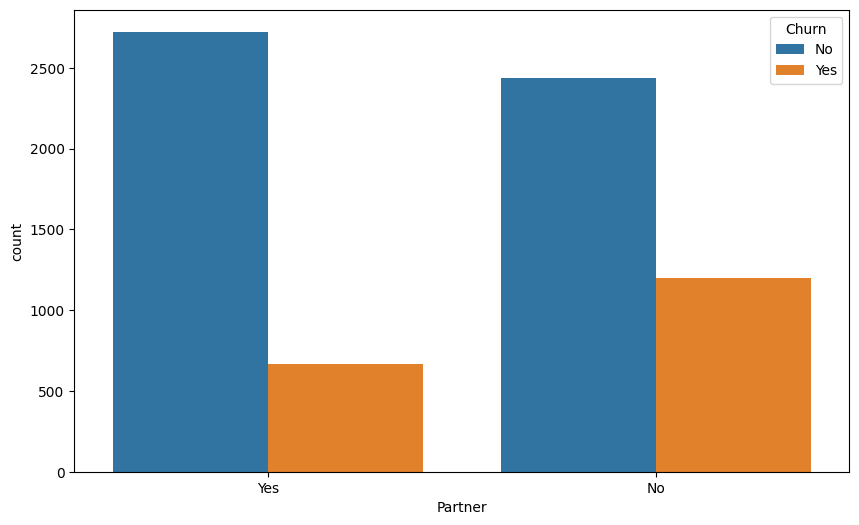

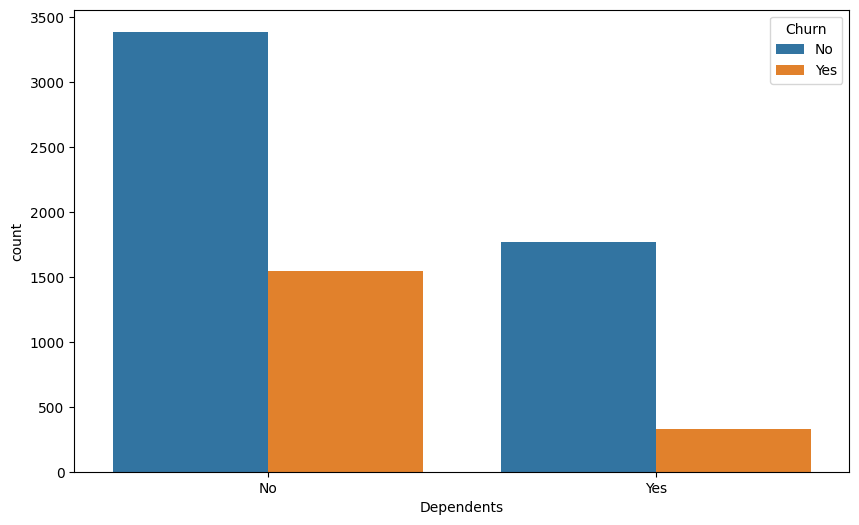

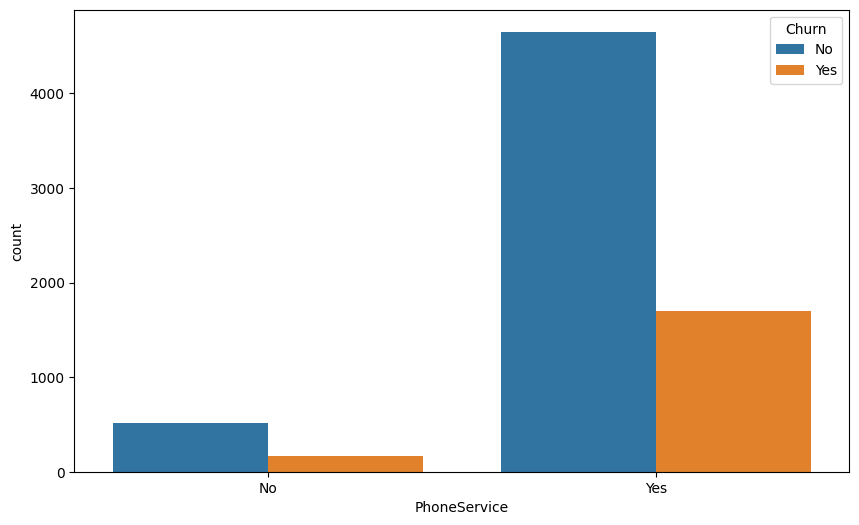

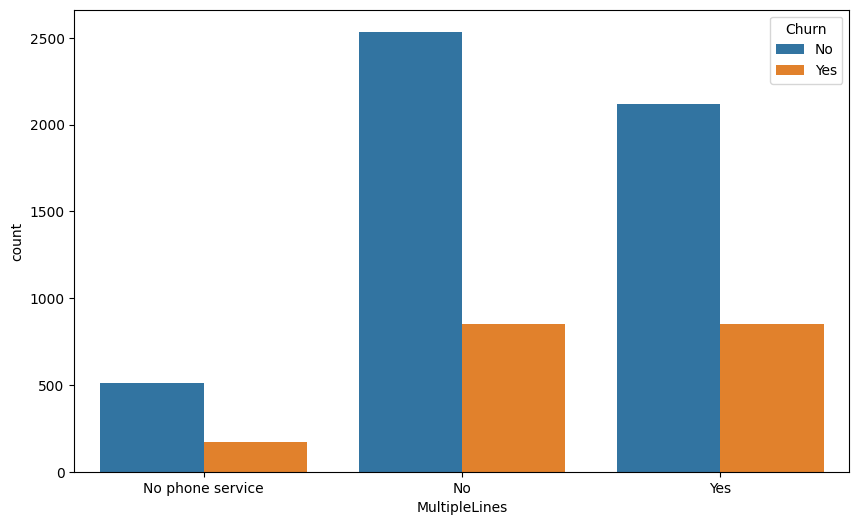

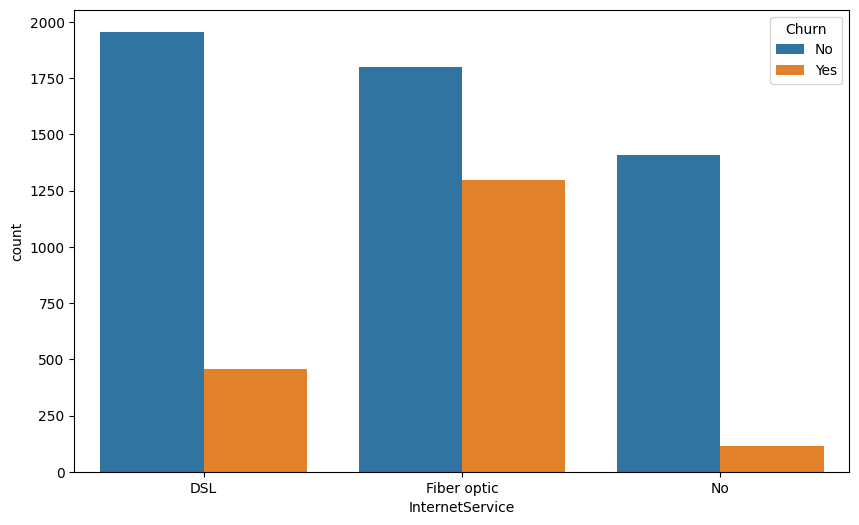

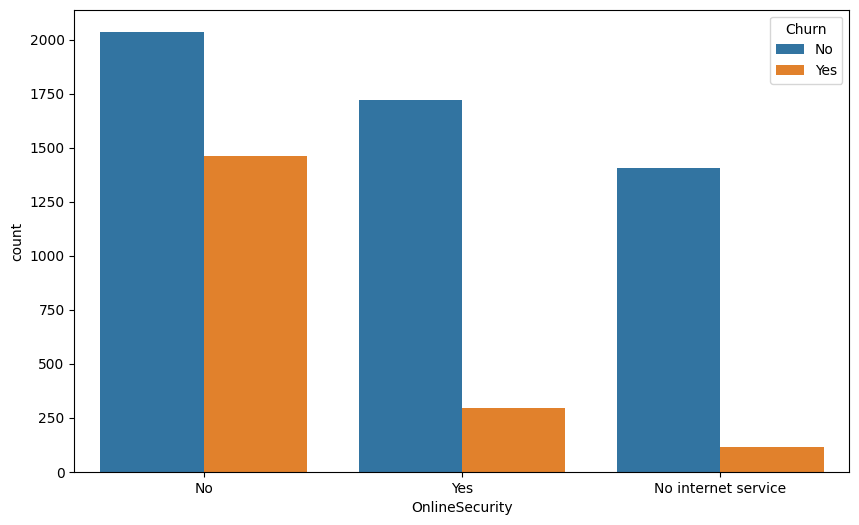

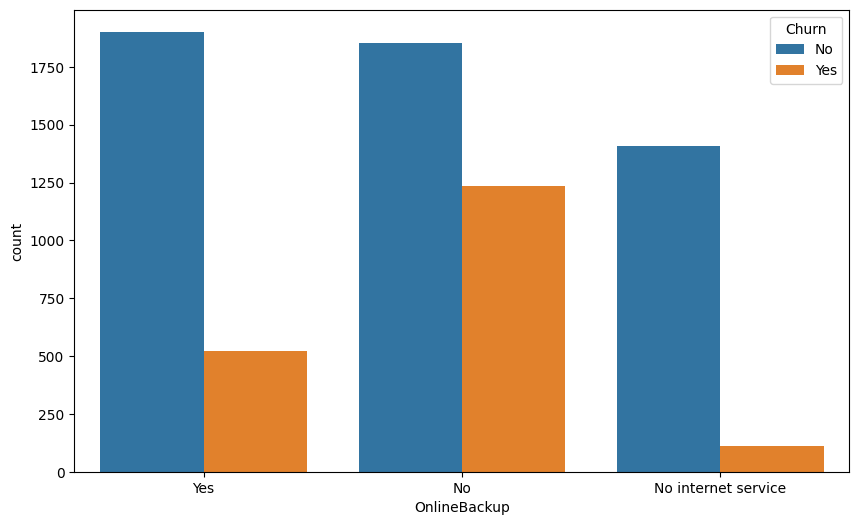

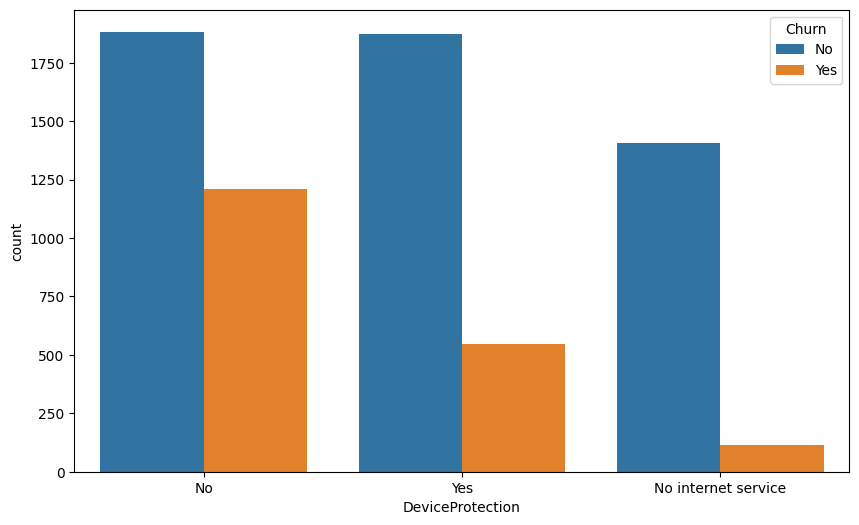

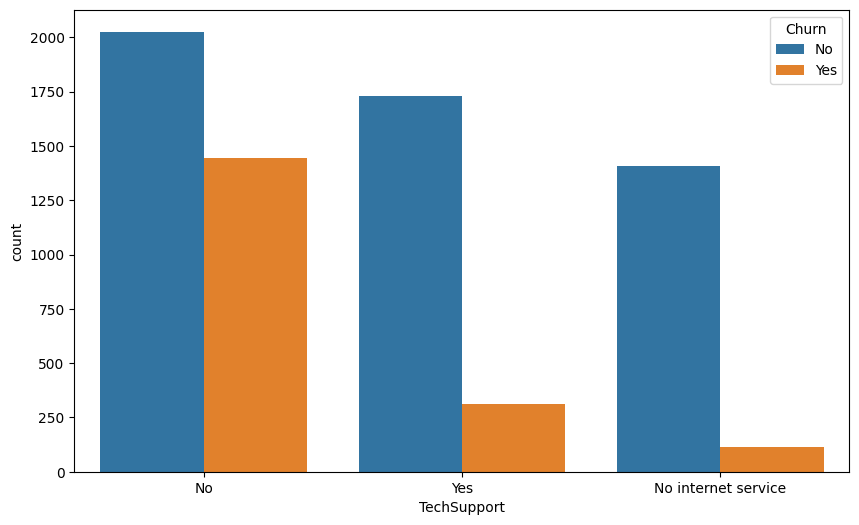

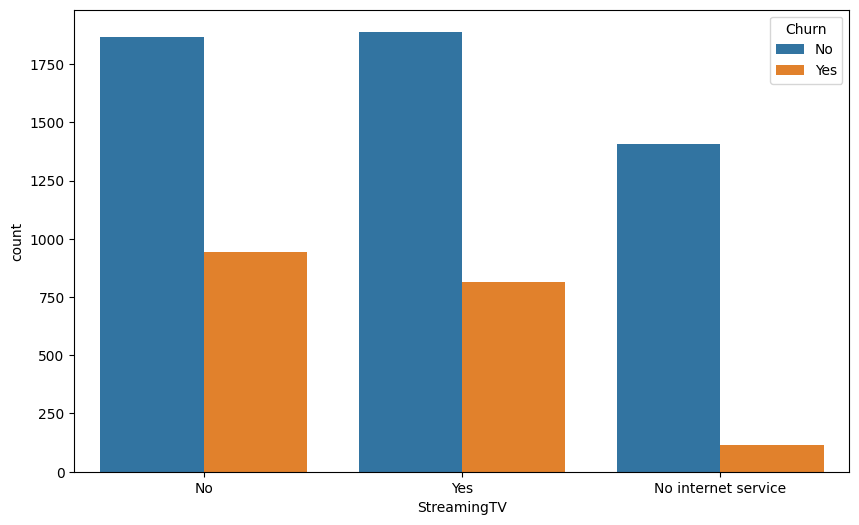

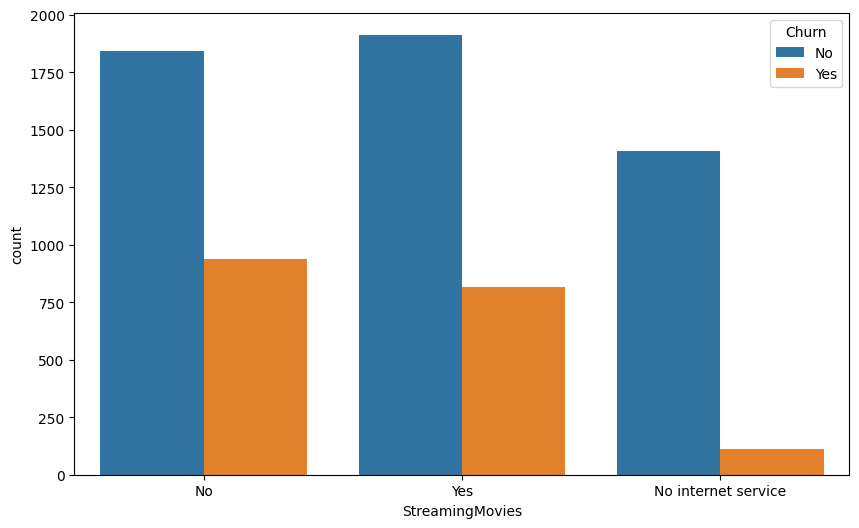

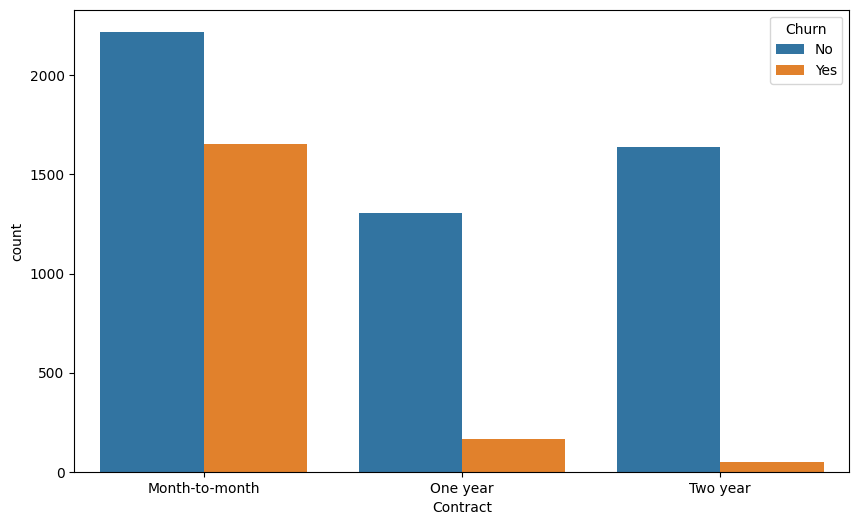

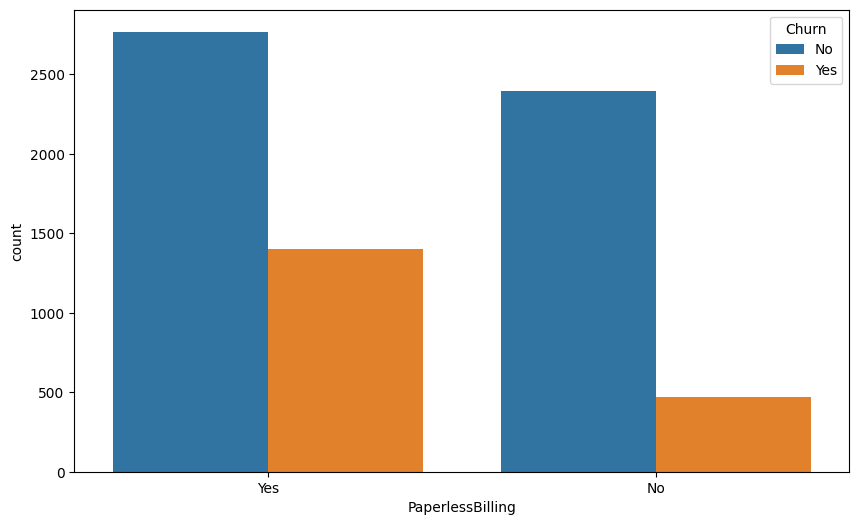

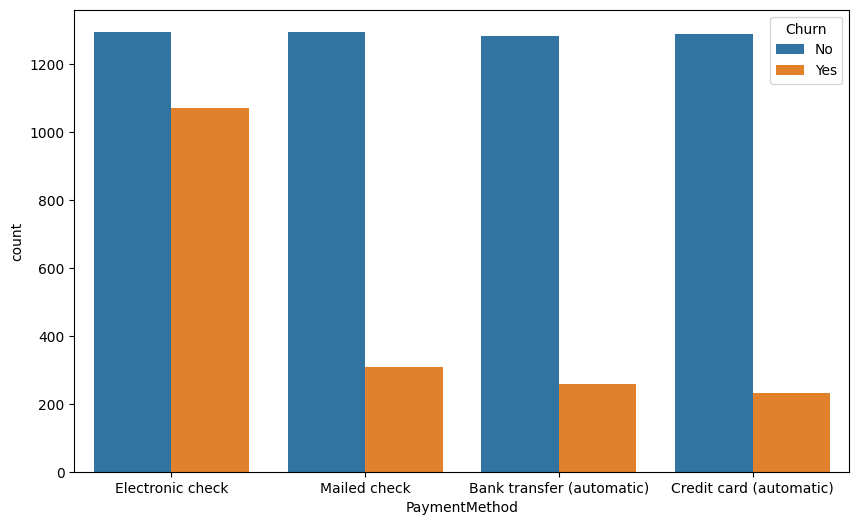

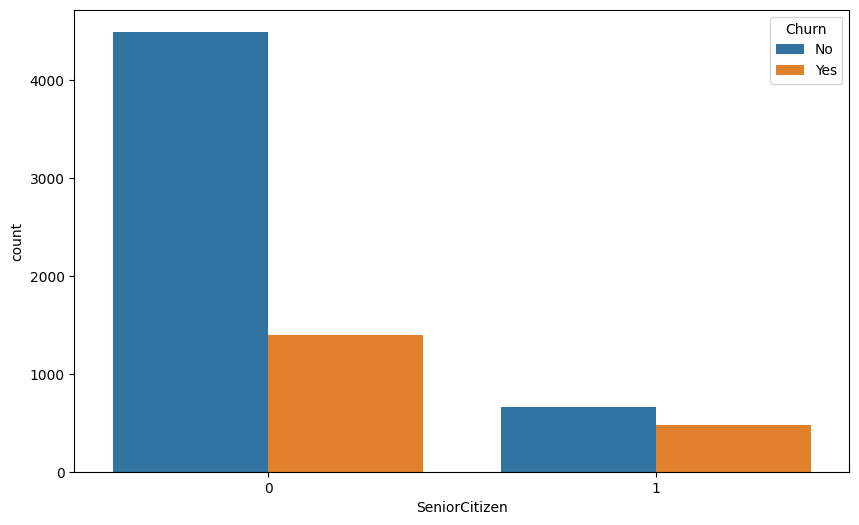

In [ ]:
# Visusalizing Categorical Data with Countplots
for col in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue='Churn', data=df_work)

# Multiple lines might be able to be cut.  Very similar looking count plots.
# StreamingTV might be able to be cut.
# Streaming Movies as well.
# The SeniorCitizen class has very few people.  Might be able to cut.
# Gender churn ratio also identical, so probably not important.

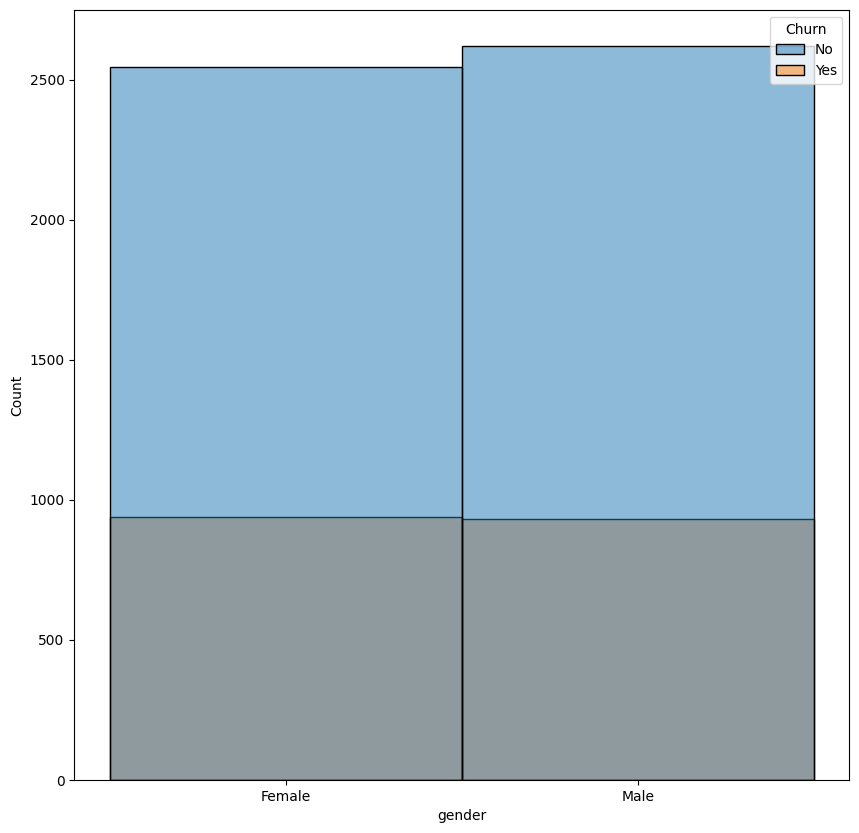

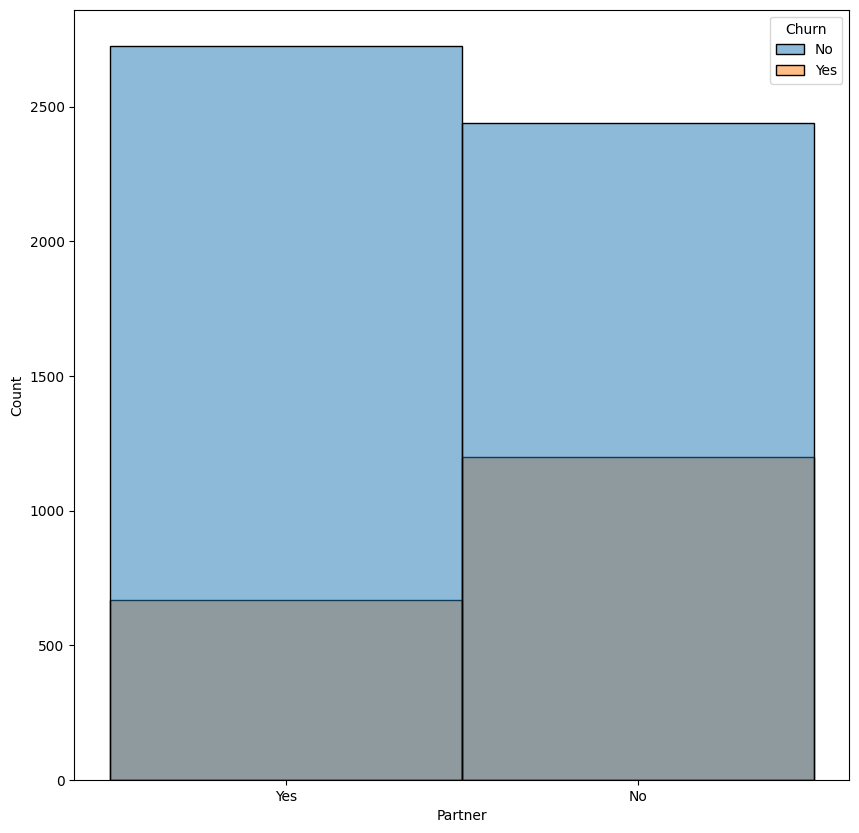

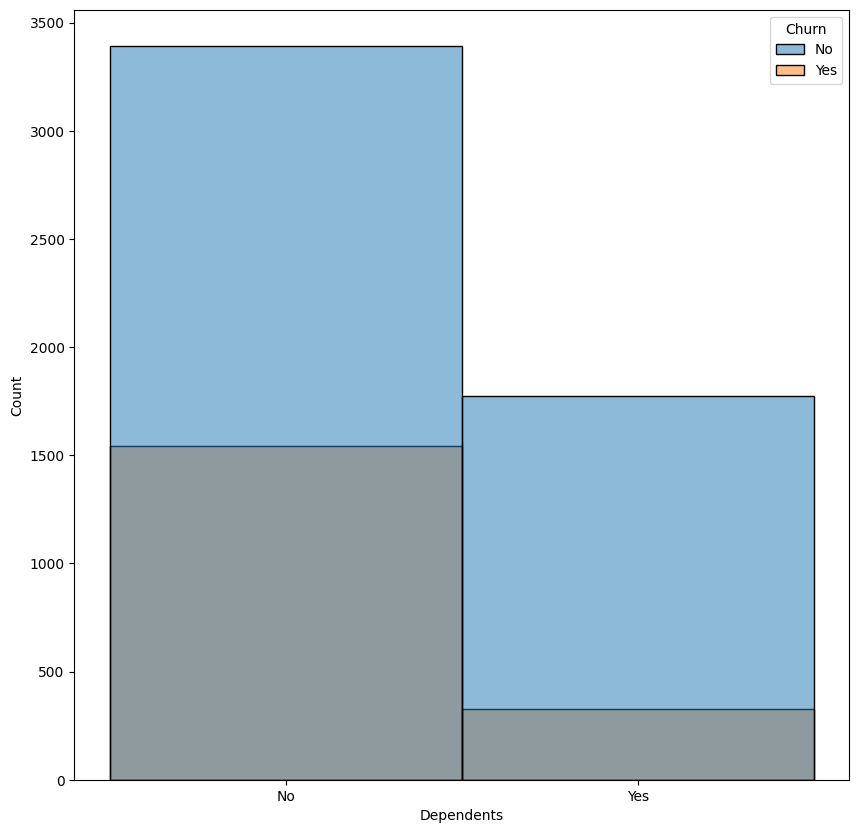

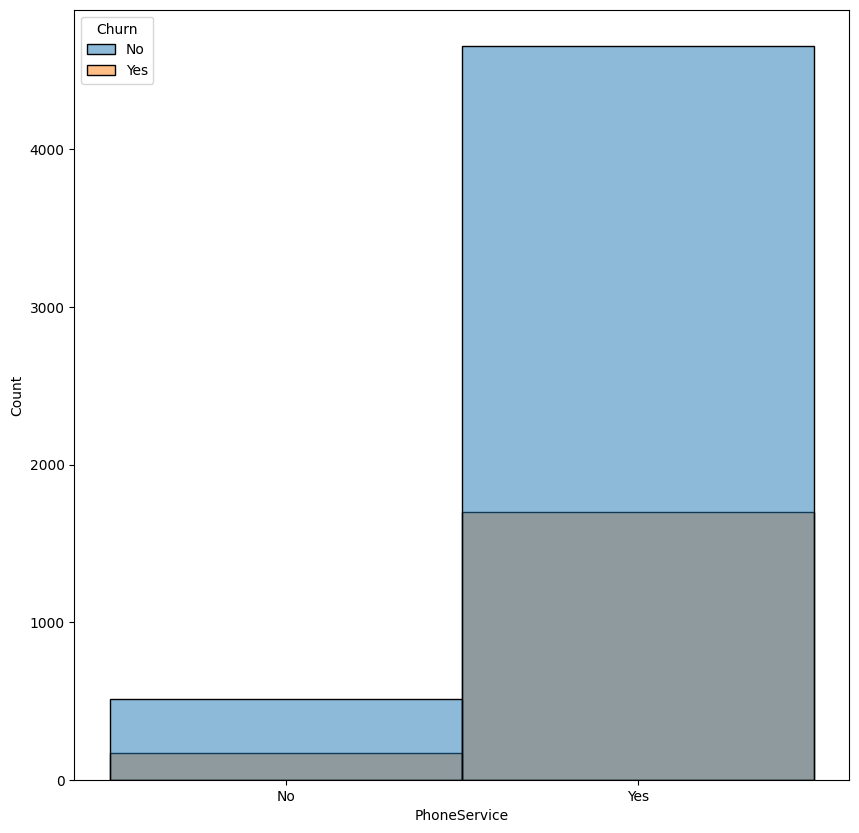

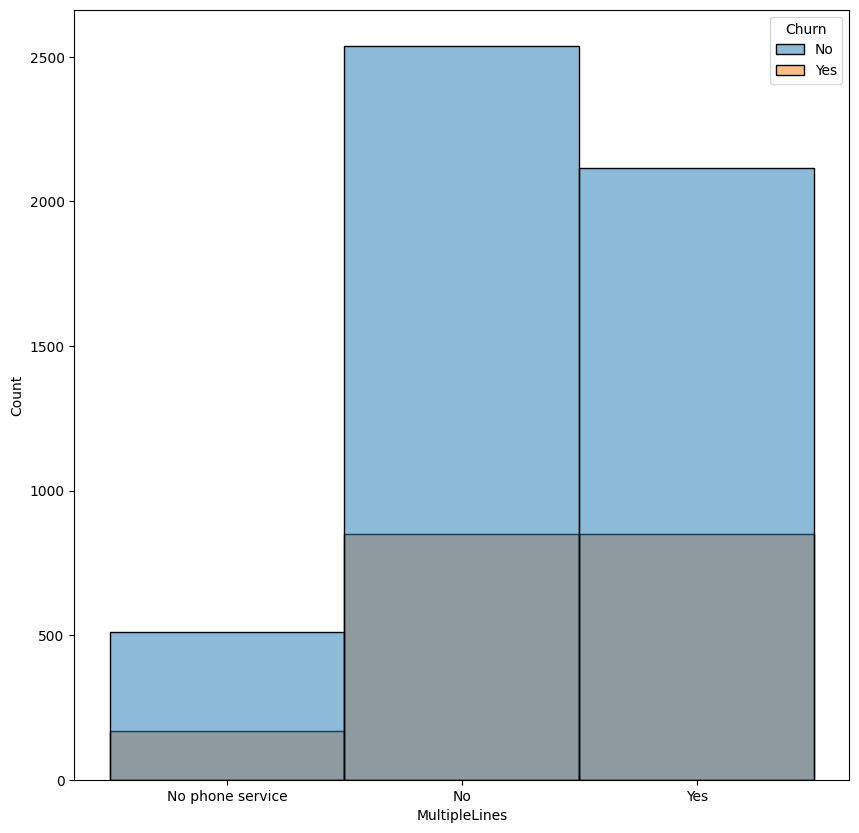

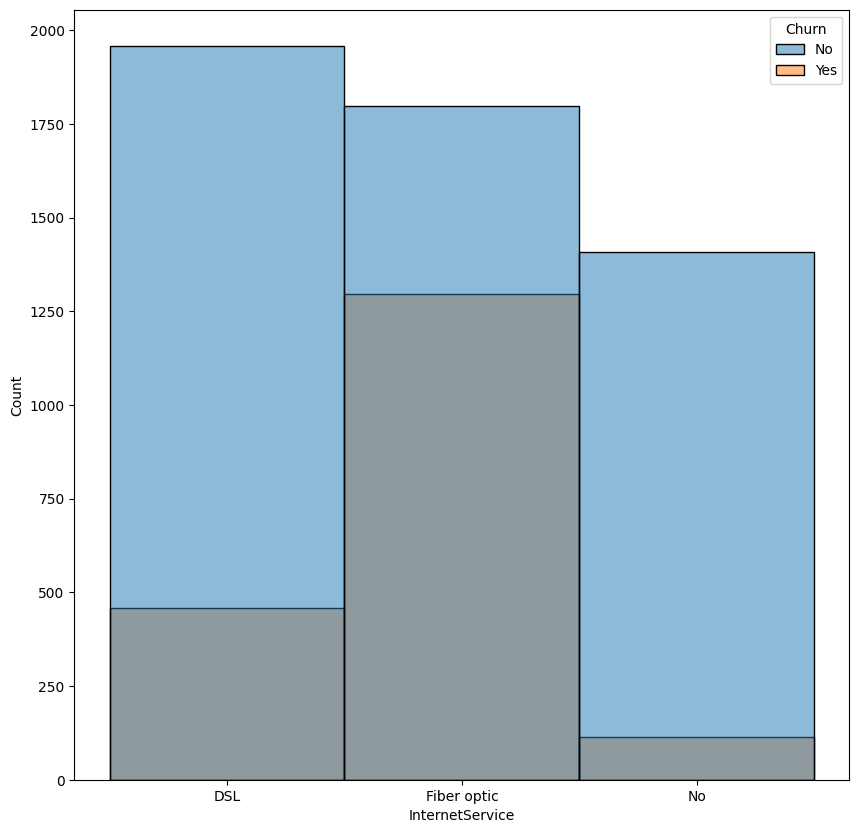

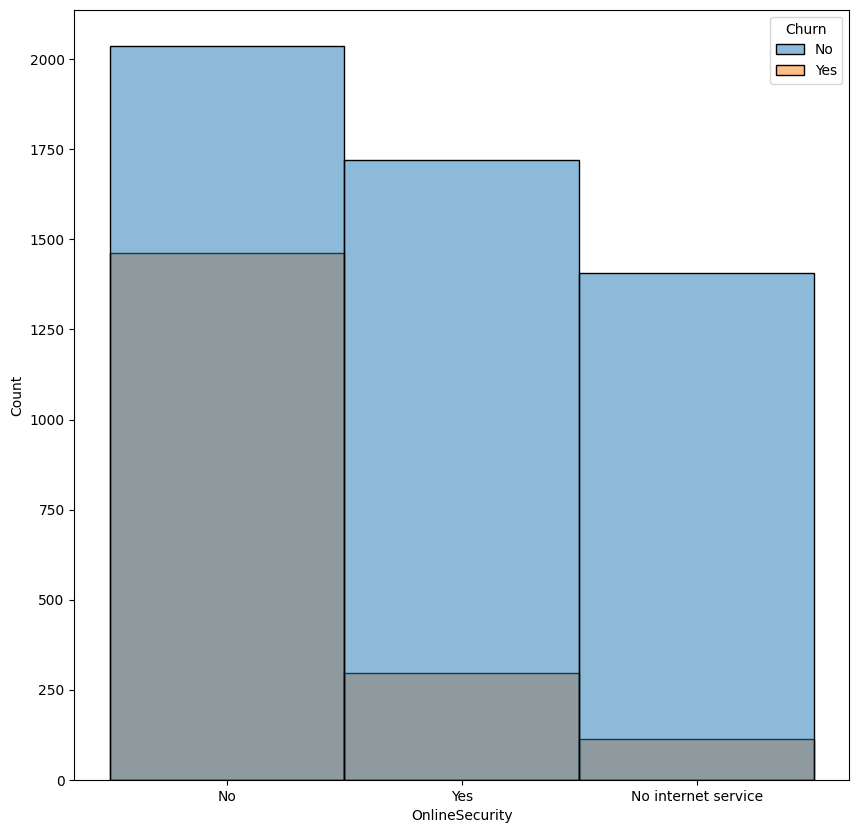

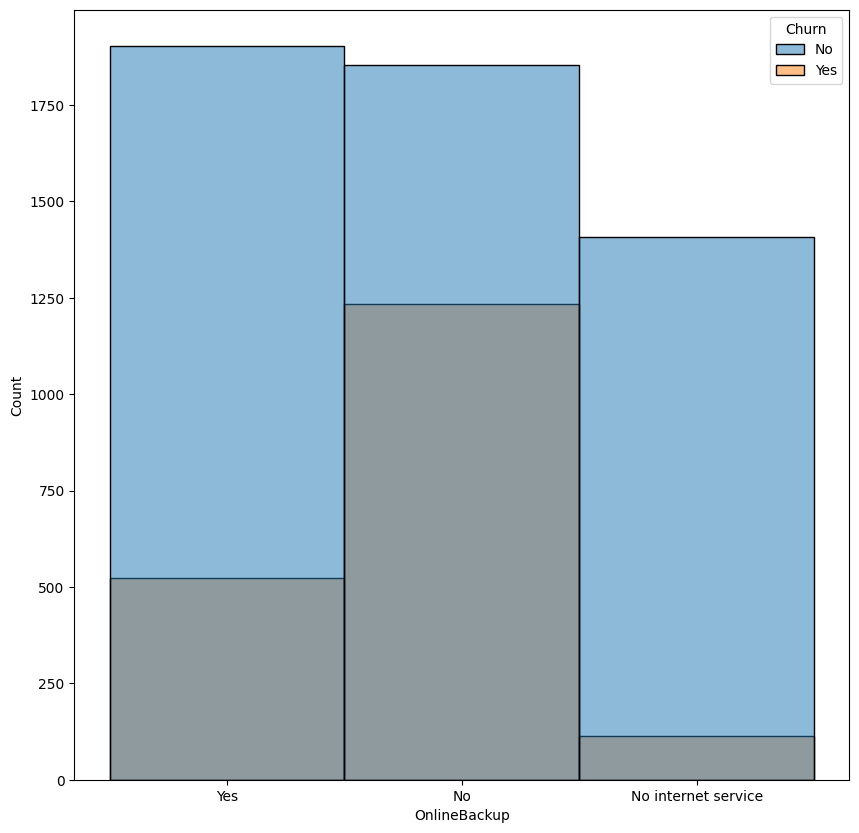

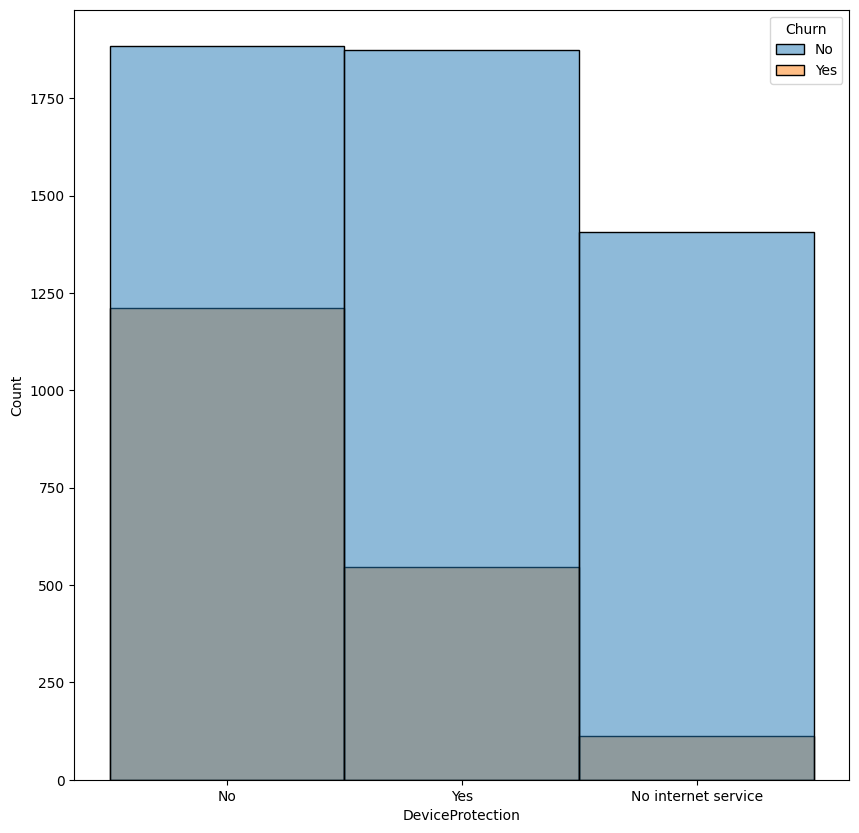

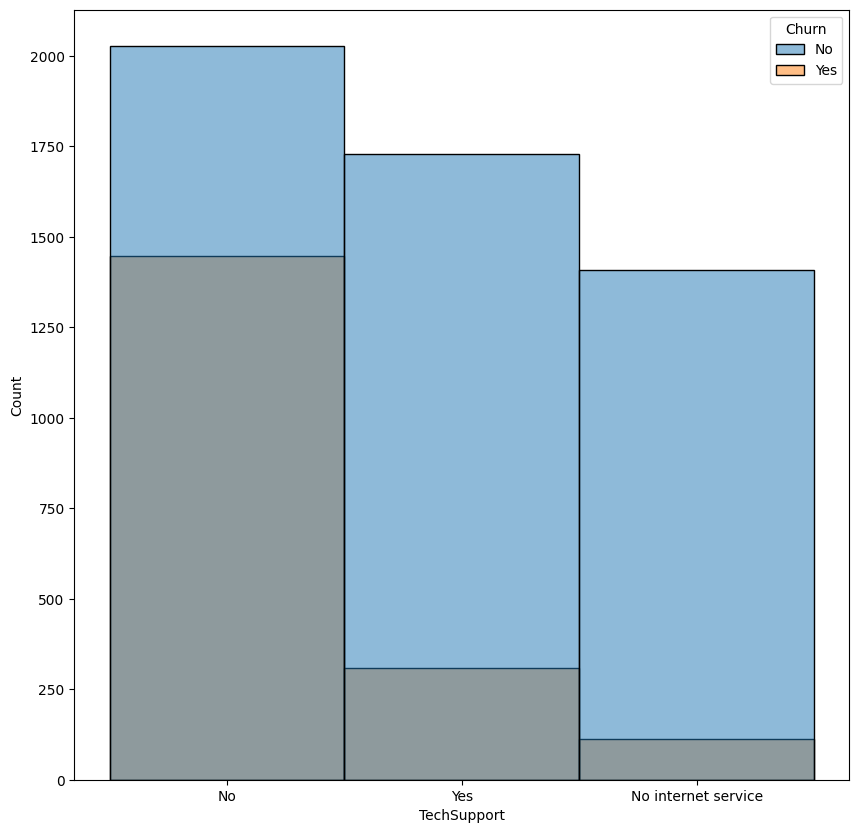

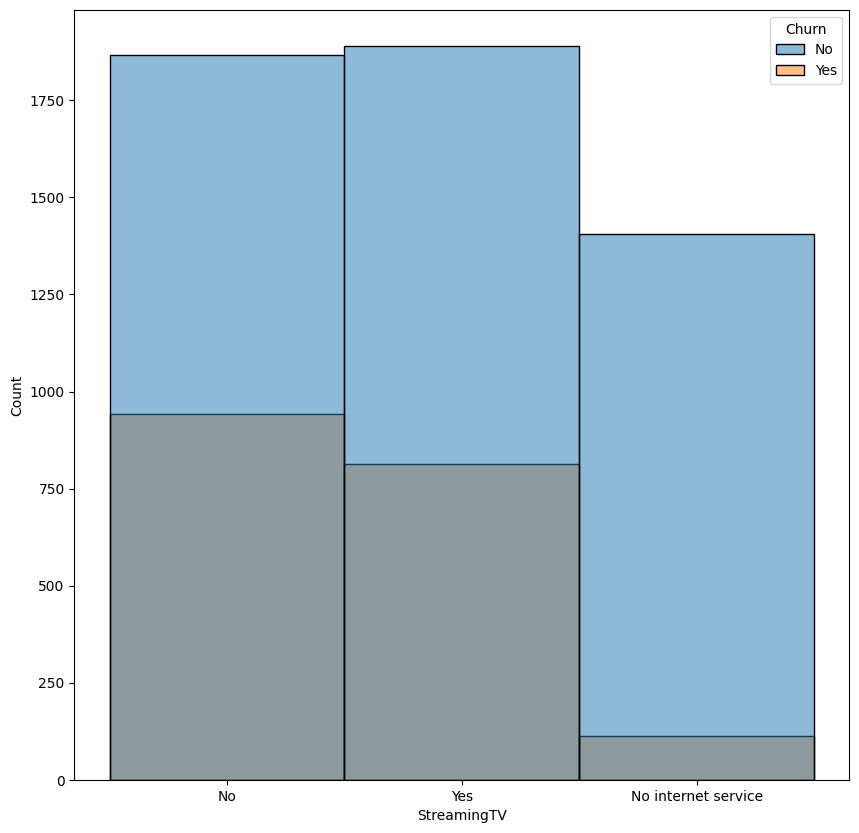

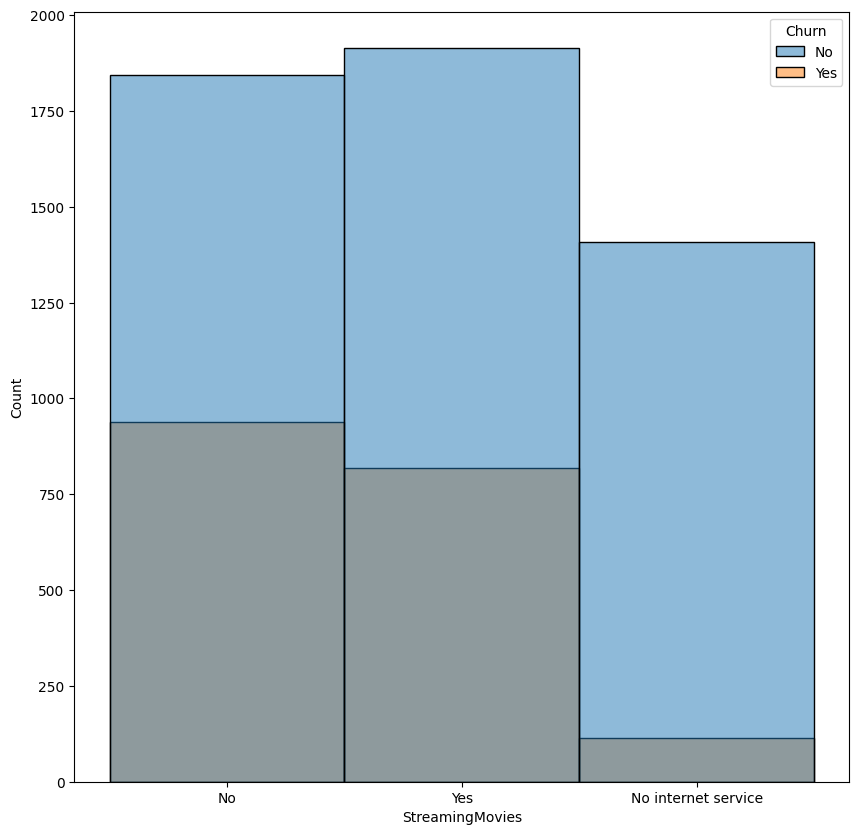

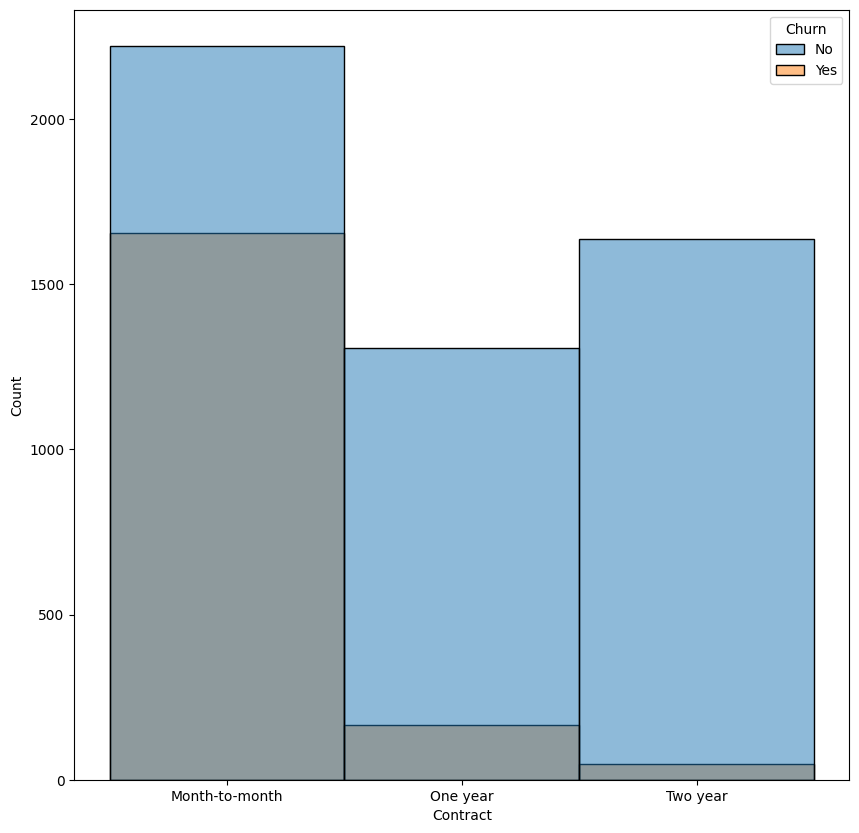

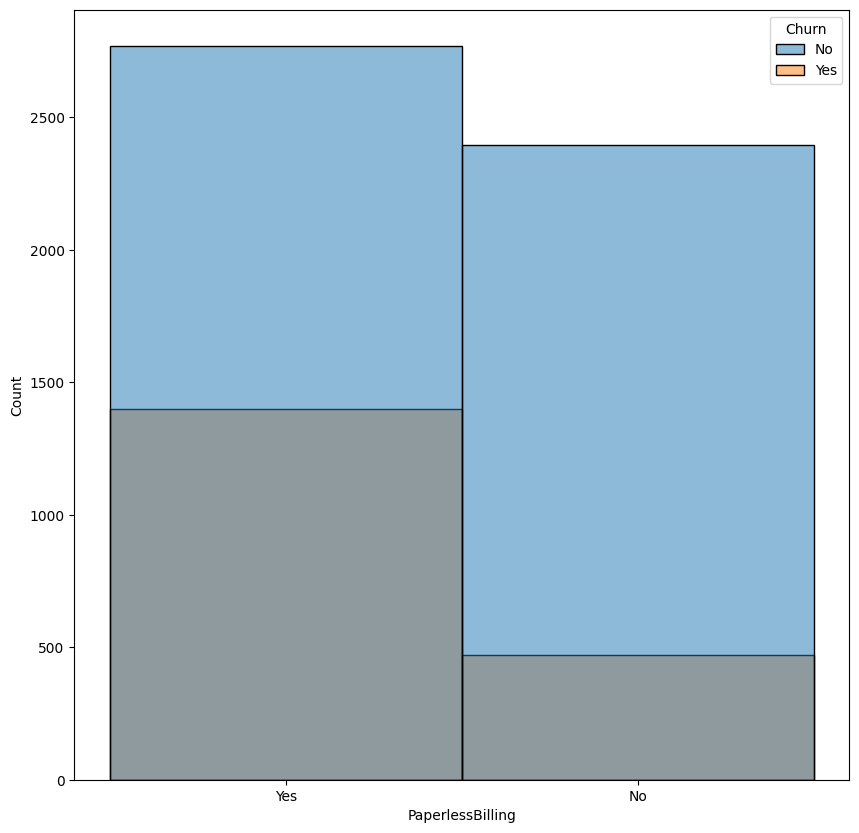

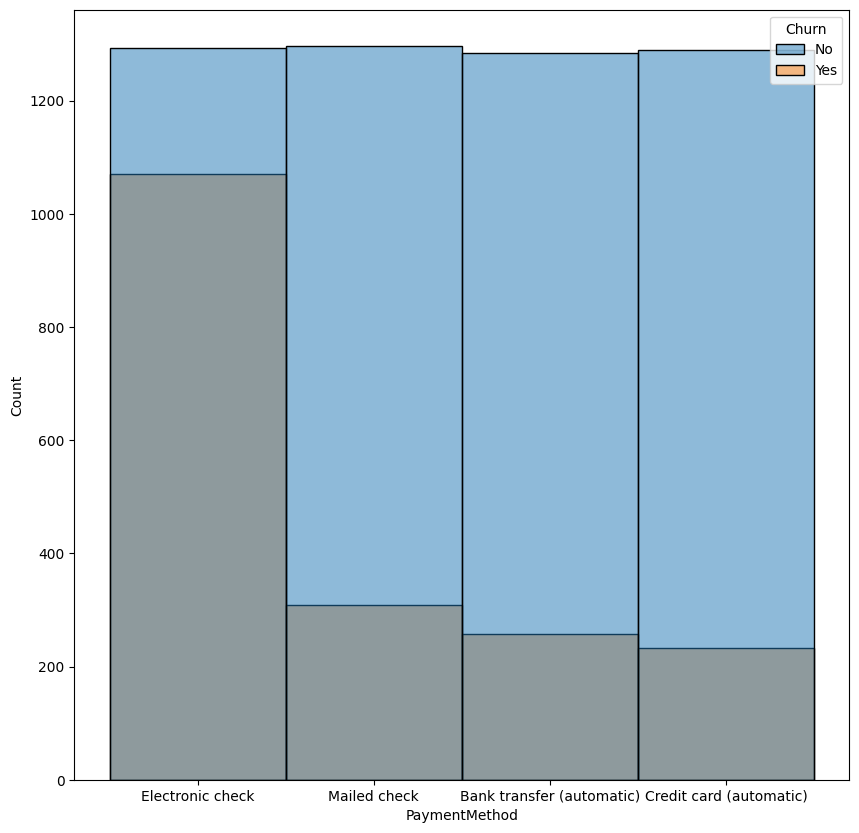

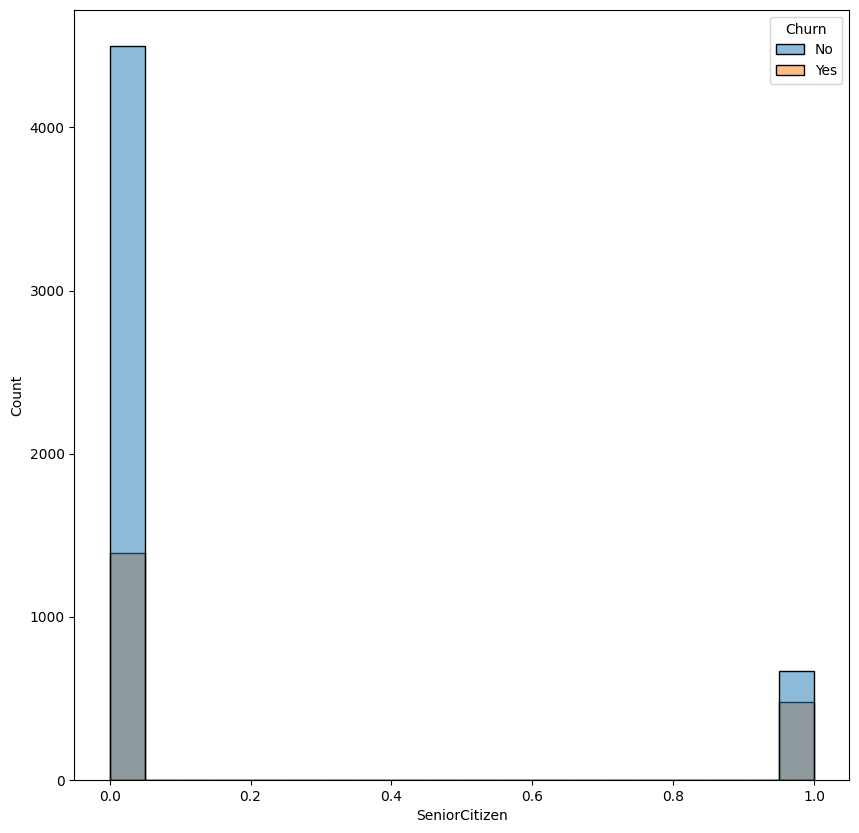

In [ ]:
# Visusalizing Categorical Data with Countplots
for col in categorical_columns:
    plt.figure(figsize=(10, 10))
    sns.histplot(x=col, hue='Churn', data=df_work, alpha=0.5, bins=20)

In [ ]:
# Zachary wrote this code to split out training, test, and verification data

# Separate training and test data
target = 'Churn'

# x has all columns EXCEPT Churn (so ML does not cheat!!)
# Additionally, customerID should have no effect on the data as it's just an ID
# Remove non-features as well before splitting
x = df_work.drop(columns=[target, 'customerID'])
# y has only Churn
y = df_work[target]

# NOTE that this section has a copy of the dataframe since we need to do a little
# transformation for the correlation map
# visualize correlation between features
# Will need to fix TotalCharges first and then deal with SeniorCitizen feature

# Encode categorical data columns
# Make a copy of the dataset
df_corr = df_work.copy()
df_corr = df_corr.drop(columns=['customerID'])

# Identify categorical and numerical columns
categorical_columns_corr = [
    col for col in df_corr.columns if df_corr[col].dtype == 'object']
numerical_columns_corr = [
    col for col in df_corr.columns if df_corr[col].dtype != 'object']

# Must move the SeniorCitizen Column in the copy
if 'SeniorCitizen' in numerical_columns_corr:
    numerical_columns_corr.remove('SeniorCitizen')

if 'SeniorCitizen' not in categorical_columns_corr:
    categorical_columns_corr.append('SeniorCitizen')

# One-hot encode categorical variables
df_categorical = pd.get_dummies(
    df_corr[categorical_columns_corr], drop_first=True)

# Drop original categorical columns
df_corr = df_corr.drop(
    columns=[col for col in categorical_columns_corr if col in df_corr.columns])

# Concatenate the one-hot encoded columns
df_corr = pd.concat([df_corr, df_categorical], axis=1)

# Standardize numerical columns
df_corr[numerical_columns_corr] = (df_corr[numerical_columns_corr] -
                                   df_corr[numerical_columns_corr].mean()) / df_corr[numerical_columns_corr].std()

# Visualize correlation
df_corr.corr().style.background_gradient(cmap='RdBu_r')

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

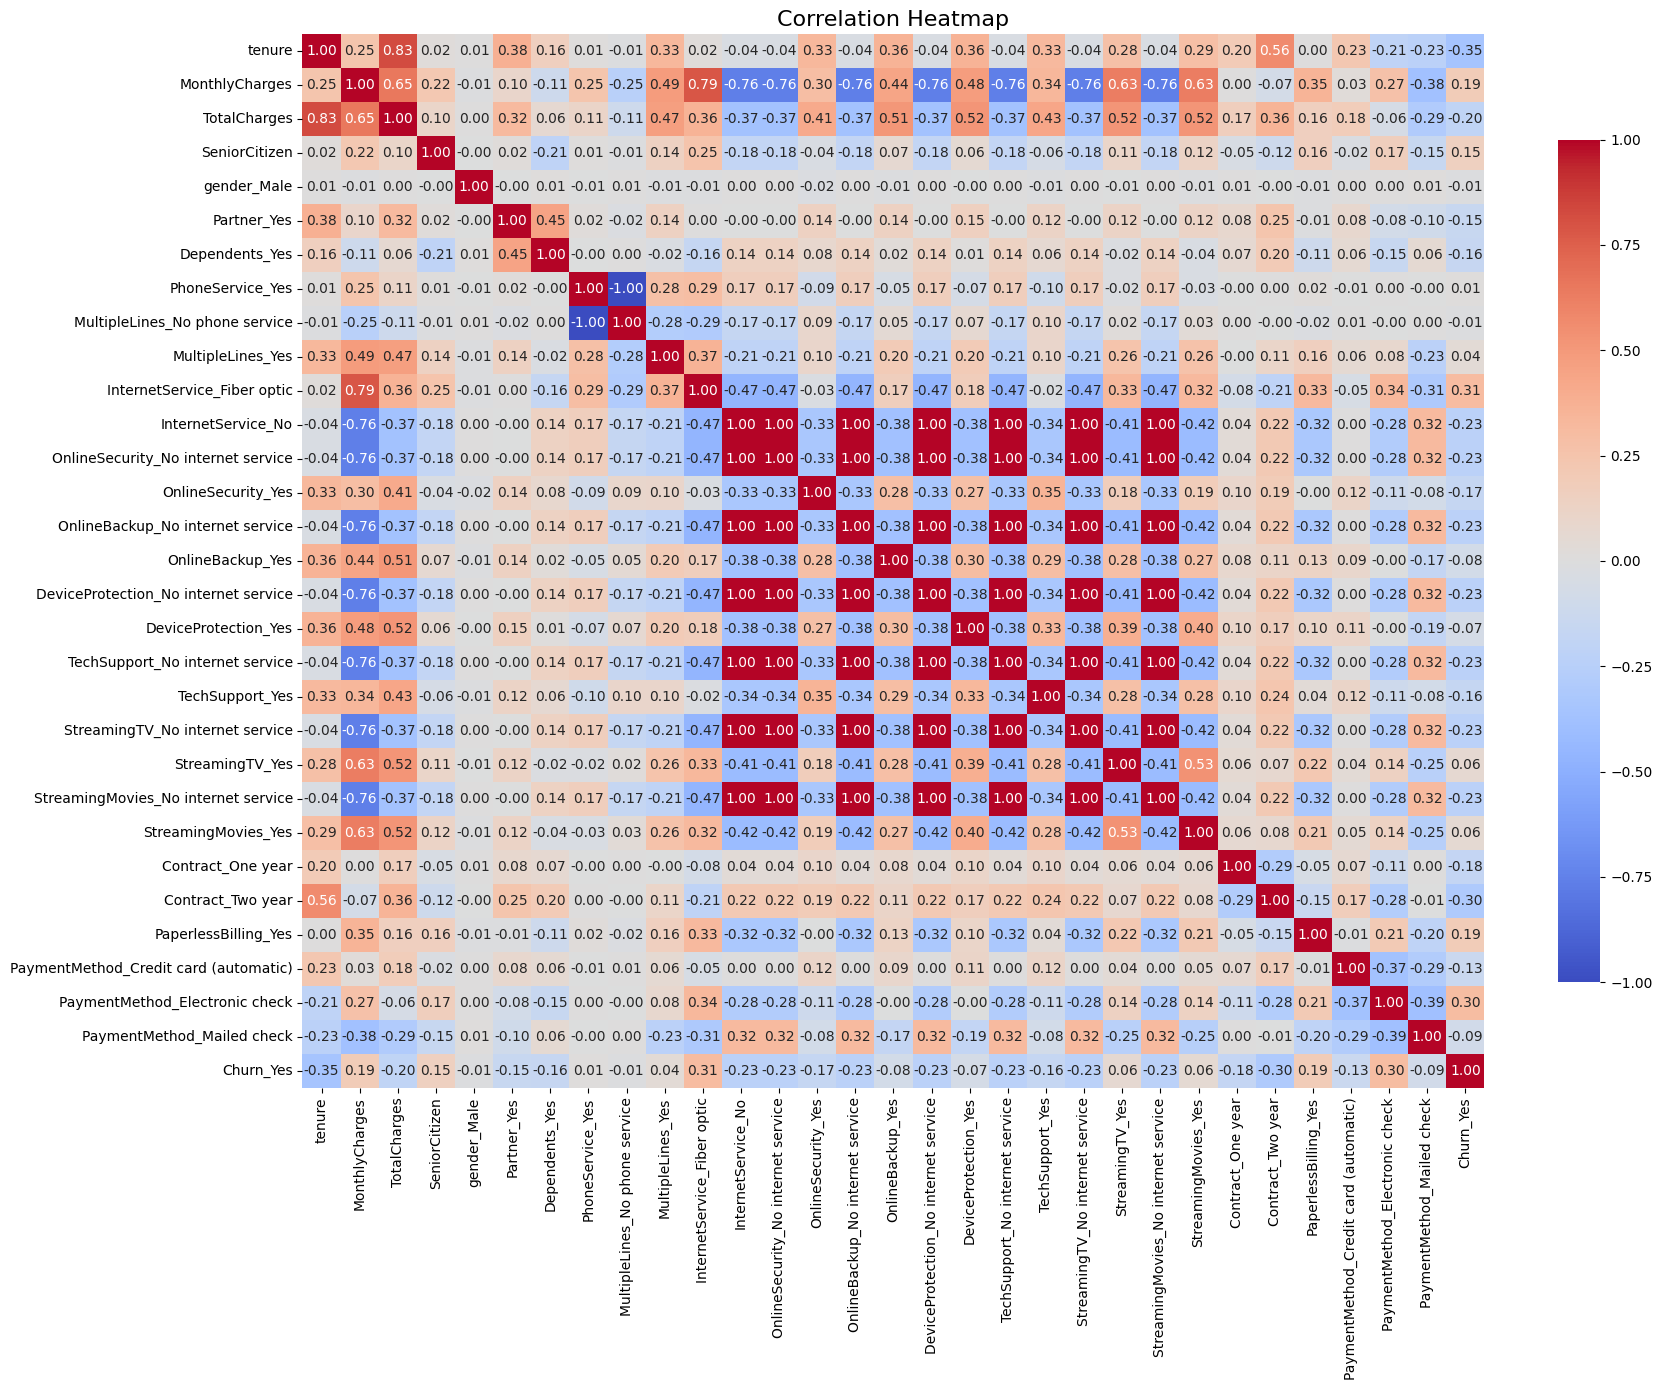

In [ ]:
plt.figure(figsize=(18, 14))
corr_matrix = df_corr.corr()
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',   # sometimes clearer than RdBu
    center=0,
    annot=True,       # turn True if you want numbers
    fmt=".2f",
    square=False,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# We can see some features with 1.0 correlation.
# This will be automatically handled by drop="first"
# when we apply one-hot endcoding for real later.
# Left these columns in the heatmap for the sake
# of the exercise.

<Axes: >

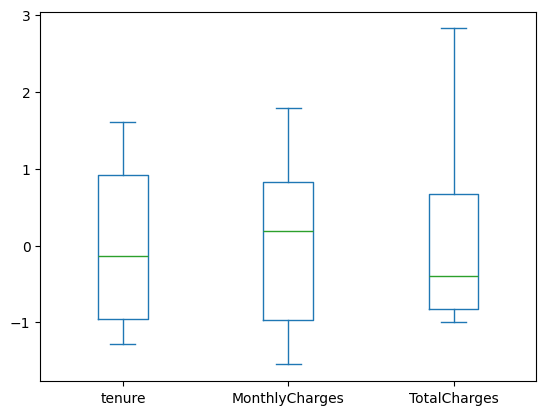

In [ ]:
# Box Plot Analysis of Numerical Data
# No true statistical outliers
# Though the whisker on TotalCharges is quite long.
df_corr[numerical_columns_corr].plot.box()

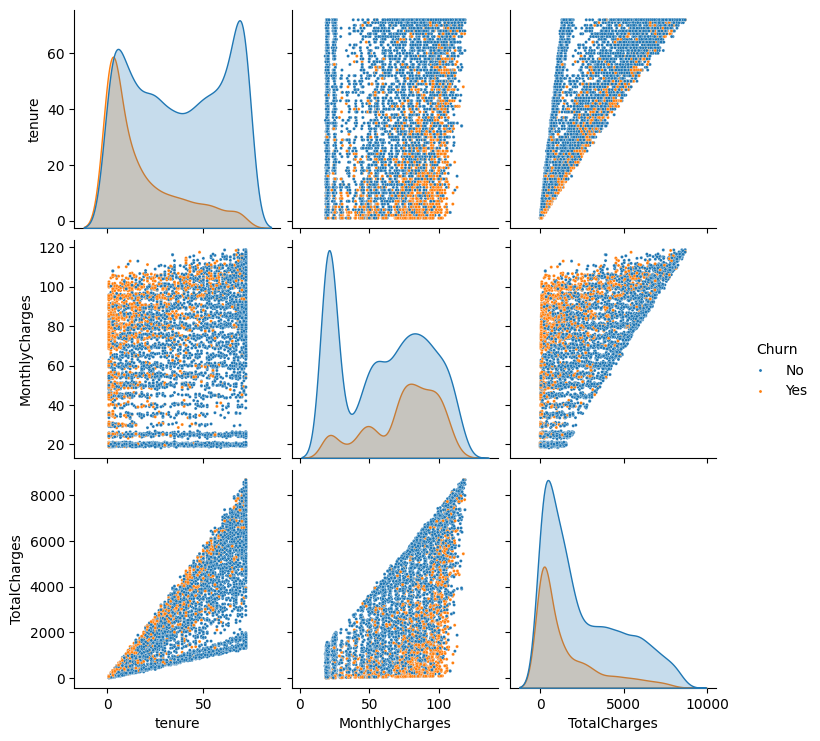

In [ ]:
# Numerical Analysis with pairplot
import seaborn as sns

sns.pairplot(
    df_work.drop(columns=['SeniorCitizen']),
    hue='Churn',
    plot_kws={'s': 5}  # smaller dots
)

In [ ]:
import plotly.express as px
# Need to normalize data here first
columns_to_normalize = ['tenure', 'MonthlyCharges', 'TotalCharges']
plot_scaler = MinMaxScaler()
normalized_values = plot_scaler.fit_transform(df_work[columns_to_normalize])

# Convert back to DataFrame with original column names
normalized_df = pd.DataFrame(
    normalized_values,
    columns=columns_to_normalize,
    index=df_work.index
)

normalized_df['Churn'] = df_work['Churn']

fig = px.scatter_3d(normalized_df, x='TotalCharges',
                    y='MonthlyCharges', z='tenure', color='Churn')
fig.update_traces(marker=dict(size=2))
fig.show()

### Analysis of Linearity of the Data Made After Model Comparison

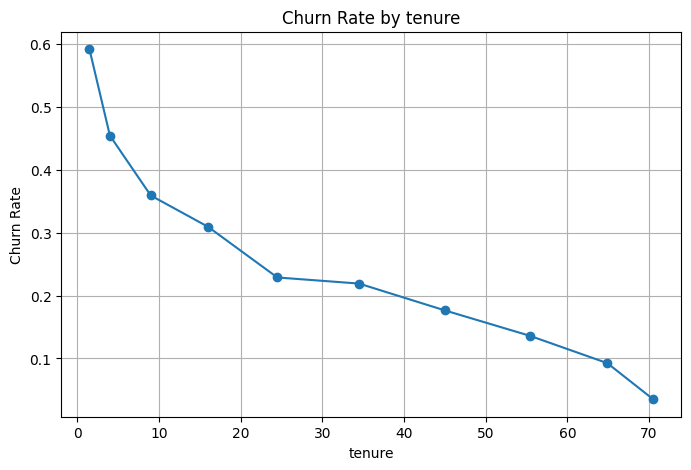

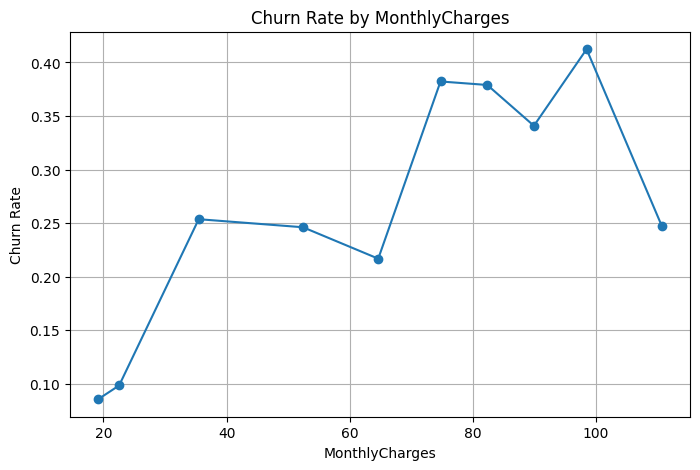

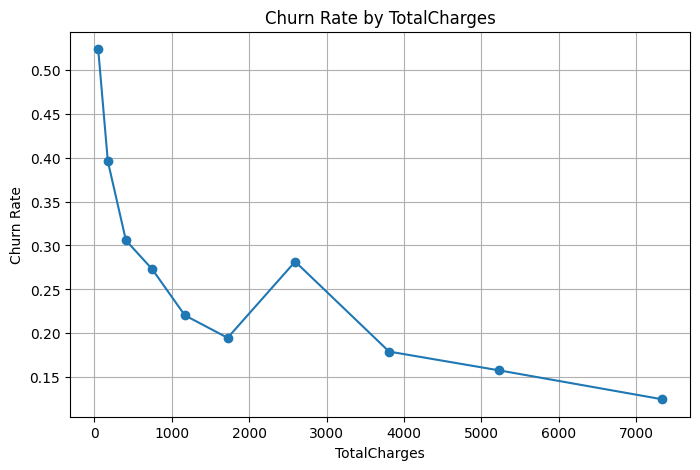

In [ ]:
# Make copy
df_plot = df_work.copy()

# Convert churn to numeric
df_plot["Churn_numeric"] = df_plot["Churn"].map({"No": 0, "Yes": 1})

# Features to analyze
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

for feature in numeric_features:

    # Drop NA
    temp_df = df_plot[[feature, "Churn_numeric"]].dropna().copy()

    # Cut into quartiles
    temp_df["feature_bin"] = pd.qcut(temp_df[feature], 10, duplicates="drop")

    # Compute churn rate per bin
    churn_by_feature = (
        temp_df.groupby("feature_bin", observed=False)["Churn_numeric"]
        .mean()
        .reset_index()
    )

    # Extract midpoint for plotting
    churn_by_feature["feature_mid"] = churn_by_feature["feature_bin"].apply(
        lambda x: x.mid)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(
        churn_by_feature["feature_mid"],
        churn_by_feature["Churn_numeric"],
        marker="o"
    )

    plt.xlabel(feature)
    plt.ylabel("Churn Rate")
    plt.title(f"Churn Rate by {feature}")
    plt.grid(True)
    plt.show()

### Set Up Transformers

In [ ]:
# Normalize the data through both MinMaxScaler (non-linear)
# and standard_scaler (linear) for different models
numeric_transformer = MinMaxScaler()
numeric_transformer_linear = StandardScaler()

# Using OneHot encoding
# Our data has very low cardinality.  In fact the highest cardinality of any
# feature is only 3.  Obvious candidate to use this for all categorical features
# NOTE: using drop="First" will automatically handle columns with 1.0 or -1.0
# Correlation, no need to remove.
categorical_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")

### Set up preprocessors

In [ ]:


preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numerical_columns),
        ("categorical", categorical_transformer, categorical_columns),
    ]
)

preprocessor_linear = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer_linear, numerical_columns),
        ("categorical", categorical_transformer, categorical_columns),
    ]
)

### Model 1: Logistic Regression
Baseline performed better than selected models! Went back and re-examined the data to determine linearity

In [ ]:
print("*" * 100)
print("*" * 100)
print("LOGISTIC REGRESSION ANALYSIS")
print("*" * 100)
print("*" * 100)
print("\n\n")

# Tunable parameters lists (simple + assignment-friendly)
# C controls regularization strength: smaller C => stronger regularization
C_candidates = [0.01, 0.1, 1, 10]
penalty_candidates = ["l1", "l2"]
class_weight_candidates = [None, "balanced"]

model_array = []
results_array = []

# Create filename with current date & time
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_filename = f"model_1_logreg_analysis_{timestamp}.txt"

print(
    f"Full analysis data for Logistic Regression can be found in {log_filename} once complete.")
print("Running... please wait.")

with open(log_filename, "a") as f:
    print("Logistic Regression Data Analysis", file=f)

for C in C_candidates:
    for penalty in penalty_candidates:
        for class_weight in class_weight_candidates:

            # - lbfgs supports l2
            # - liblinear supports l1/l2 (binary), good for small datasets

            solver_to_use = "lbfgs"
            if penalty == "l1":
                solver_to_use = "liblinear"

            logreg_model_pipeline = Pipeline(
                steps=[
                    ("preprocessor", preprocessor_linear),
                    ("model", LogisticRegression(
                        max_iter=1000,
                        C=C,
                        penalty=penalty,
                        solver=solver_to_use,
                        class_weight=class_weight
                    ))
                ]
            )

            logreg_model_pipeline.fit(x_training, y_training)

            with open(log_filename, "a") as f:
                print("=" * 50, file=f)
                print("START RESULTS WITH PARAMETERS:", file=f)
                print(f"C: {C}", file=f)
                print(f"penalty: {penalty}", file=f)
                print(f"solver: {solver_to_use}", file=f)
                print(f"class_weight: {class_weight}", file=f)

            # Training set performance
            logreg_y_train_pred = logreg_model_pipeline.predict(x_training)
            with open(log_filename, "a") as f:
                print("\n Training Set Results", file=f)
                print(confusion_matrix(y_training, logreg_y_train_pred), file=f)
                print(classification_report(
                    y_training, logreg_y_train_pred), file=f)

            # Validation set performance
            logreg_y_validation_pred = logreg_model_pipeline.predict(
                x_validation)
            with open(log_filename, "a") as f:
                print("\n Validation Set Results", file=f)
                print(confusion_matrix(y_validation,
                      logreg_y_validation_pred), file=f)
                print(classification_report(y_validation,
                      logreg_y_validation_pred), file=f)

            # Test set performance
            logreg_y_test_pred = logreg_model_pipeline.predict(x_test)
            with open(log_filename, "a") as f:
                print("\n Test Set Results", file=f)
                print(confusion_matrix(y_test, logreg_y_test_pred), file=f)
                print(classification_report(y_test, logreg_y_test_pred), file=f)

            # Send to report
            results_array.append({
                "C": C,
                "penalty": penalty,
                "solver": solver_to_use,
                "class_weight": class_weight,
                "training_accuracy": logreg_model_pipeline.score(x_training, y_training),
                "validation_accuracy": logreg_model_pipeline.score(x_validation, y_validation),
                "test_accuracy": logreg_model_pipeline.score(x_test, y_test),
                "model": logreg_model_pipeline
            })


best_training = max(results_array, key=lambda x: x["training_accuracy"])
print("\n")
print("=" * 100)
print("Best Training Accuracy Model:")
print(best_training)

print("\n")
print("=" * 100)
best_validation = max(results_array, key=lambda x: x["validation_accuracy"])
print("Best Validation Accuracy Model:")
print(best_validation)

print("\n")
print("=" * 100)
best_test = max(results_array, key=lambda x: x["test_accuracy"])
print("Best Test Accuracy Model:")
print(best_test)

# This is finding the smallest differenct between training and validation
# accuracy, and choosing the highes validation accuracy
# in the event of a tie.  Note that it is -x["validation_accuracy"] rather
# than positive because we are taking the min() and this function would choose
# the lower of these values, so inverting it will give you the highest
# validation accuracy
# Equation adapted from principles found in
# https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff
best_balanced = min(
    results_array,
    key=lambda x: (
        abs(x["training_accuracy"] - x["validation_accuracy"]),
        -x["validation_accuracy"]
    )
)

print("\n")
print("=" * 100)
print("Best Least-Overfit Validation Model:")
print(best_balanced)

logreg_analysis_balanced_file_name = f"churn_logistic_regression_model_balanced_{timestamp}.pkl"
joblib.dump(best_balanced["model"], logreg_analysis_balanced_file_name)
print(f"Saved best_balanced model to {logreg_analysis_balanced_file_name}")

logreg_analysis_acc_val_file_name = f"churn_logistic_regression_model_acc_val_{timestamp}.pkl"
joblib.dump(best_validation["model"], logreg_analysis_acc_val_file_name)
print(
    f"Saved best validation accuracy model to {logreg_analysis_acc_val_file_name}")

models = [best_validation]

****************************************************************************************************
****************************************************************************************************
LOGISTIC REGRESSION ANALYSIS
****************************************************************************************************
****************************************************************************************************



Full analysis data for Logistic Regression can be found in model_1_logreg_analysis_2026-03-02_19-20-04.txt once complete.
Running... please wait.


Best Training Accuracy Model:
{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear', 'class_weight': None, 'training_accuracy': 0.8059731816334823, 'validation_accuracy': 0.8018957345971564, 'test_accuracy': 0.8056872037914692, 'model': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  Index(['MonthlyCharge

Assessing Features Importance - Logistic Regression

In [ ]:
# Using the best highest validation accuracy with good fit from above
best_lr_pipeline = best_validation["model"]

# Getting the fitted preprocessor and fitted logistic regression model
pre = best_lr_pipeline.named_steps["preprocessor"]
lr_model = best_lr_pipeline.named_steps["model"]

# Getting feature names after OneHotEncoding
ohe = pre.named_transformers_["categorical"]
cat_feature_names = ohe.get_feature_names_out(categorical_columns)

all_feature_names = np.concatenate([numerical_columns, cat_feature_names])

# Logistic Regression coefficients
coefs = lr_model.coef_[0]

lr_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefs,
    "Abs_Coefficient": np.abs(coefs)
}).sort_values("Abs_Coefficient", ascending=False)

print("Top 20 Logistic Regression Important Features (by coefficient magnitude):")
print(lr_importance.head(20))

Top 20 Logistic Regression Important Features (by coefficient magnitude):
                                 Feature  Coefficient  Abs_Coefficient
2                                 tenure    -1.456742         1.456742
24                     Contract_Two year    -1.326671         1.326671
9            InternetService_Fiber optic     0.943883         0.943883
1                           TotalCharges     0.692233         0.692233
23                     Contract_One year    -0.646919         0.646919
6                       PhoneService_Yes    -0.497306         0.497306
12                    OnlineSecurity_Yes    -0.402038         0.402038
25                  PaperlessBilling_Yes     0.322583         0.322583
22                   StreamingMovies_Yes     0.321465         0.321465
27        PaymentMethod_Electronic check     0.316522         0.316522
18                       TechSupport_Yes    -0.311407         0.311407
8                      MultipleLines_Yes     0.249137         0.249137
20 

# Model 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("*" * 100)
print("*" * 100)
print("RANDOM FOREST ANALYSIS")
print("*" * 100)
print("*" * 100)
print("\n\n")

# n_estimators: Number of trees in the forest (more trees = better but slower)
# max_depth: Maximum depth of the tree (controls model complexity)
# min_samples_split: Minimum samples required to split a node

n_estimator_candidates = [100, 200, 300]
max_depth_candidates = [5, 10, 15, 20]
min_samples_split_candidates = [2, 5, 10]

model_array = []
results_array = []

# Create filename with current date & time for logging results
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_filename = f"model_2_rf_analysis_{timestamp}.txt"

print(
    f"Full analysis data for Random Forest can be found in {log_filename} once complete.")
print("Running... please wait.")

with open(log_filename, "a") as f:
    print("Random Forest Data Analysis", file=f)

for n_estimator in n_estimator_candidates:
    for max_depth in max_depth_candidates:
        for min_samples_split in min_samples_split_candidates:
            rf_model_pipeline = Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("model", RandomForestClassifier(
                        random_state=123,
                        n_estimators=n_estimator,
                        max_depth=max_depth,
                        min_samples_split=min_samples_split,
                        n_jobs=-1
                    ))
                ]
            )

            rf_model_pipeline.fit(x_training, y_training)

            with open(log_filename, "a") as f:
                print("=" * 50, file=f)
                print("START RESULTS WITH PARAMETERS:", file=f)
                print(f"n_estimators: {n_estimator}", file=f)
                print(f"max_depth: {max_depth}", file=f)
                print(f"min_samples_split: {min_samples_split}", file=f)

            # TRAINING SET EVALUATION
            rf_y_train_pred = rf_model_pipeline.predict(x_training)
            with open(log_filename, "a") as f:
                print("\n Training Set Results", file=f)
                print(confusion_matrix(y_training, rf_y_train_pred), file=f)
                print(classification_report(y_training, rf_y_train_pred), file=f)

            # VALIDATION SET EVALUATION
            rf_y_validation_pred = rf_model_pipeline.predict(x_validation)
            with open(log_filename, "a") as f:
                print("\n Validation Set Results", file=f)
                print(confusion_matrix(y_validation, rf_y_validation_pred), file=f)
                print(classification_report(
                    y_validation, rf_y_validation_pred), file=f)

            # TEST SET EVALUATION
            rf_y_test_pred = rf_model_pipeline.predict(x_test)
            with open(log_filename, "a") as f:
                print("\n Test Set Results", file=f)
                print(confusion_matrix(y_test, rf_y_test_pred), file=f)
                print(classification_report(y_test, rf_y_test_pred), file=f)

            # Store results in array for later analysis
            results_array.append({
                "n_estimators": n_estimator,
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "training_accuracy": rf_model_pipeline.score(x_training, y_training),
                "validation_accuracy": rf_model_pipeline.score(x_validation, y_validation),
                "test_accuracy": rf_model_pipeline.score(x_test, y_test),
                "model": rf_model_pipeline
            })


best_training = max(results_array, key=lambda x: x["training_accuracy"])
print("\n")
print("=" * 100)
print("Training Accuracy Model:")
print(best_training)

print("\n")
print("=" * 100)
best_validation = max(results_array, key=lambda x: x["validation_accuracy"])
print("Validation Accuracy Model:")
print(best_validation)

print("\n")
print("=" * 100)
best_test = max(results_array, key=lambda x: x["test_accuracy"])
print("Test Accuracy Model:")
print(best_test)

# This finds the model with the smallest gap between training and validation
# accuracy (least overfit) while maintaining highest validation accuracy.
# This helps prevent overfitting and ensures good generalization.
best_balanced = min(
    results_array,
    key=lambda x: (
        abs(x["training_accuracy"] - x["validation_accuracy"]),
        -x["validation_accuracy"]
    )
)

print("\n")
print("=" * 100)
print("Least-Overfit Validation Model:")
print(best_balanced)

rf_analysis_balanced_file_name = f"churn_random_forest_model_balanced_{timestamp}.pkl"
joblib.dump(best_balanced["model"], rf_analysis_balanced_file_name)
print(f"Saved best_balanced model to {rf_analysis_balanced_file_name}")

rf_analysis_acc_val_file_name = f"churn_random_forest_model_acc_val_{timestamp}.pkl"
joblib.dump(best_validation["model"], rf_analysis_acc_val_file_name)
print(
    f"Saved best validation accuracy model to {rf_analysis_acc_val_file_name}")


models.append(best_balanced)

****************************************************************************************************
****************************************************************************************************
RANDOM FOREST ANALYSIS
****************************************************************************************************
****************************************************************************************************



Full analysis data for Random Forest can be found in model_2_rf_analysis_2026-03-02_19-20-13.txt once complete.
Running... please wait.


Training Accuracy Model:
{'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'training_accuracy': 0.9973587972368956, 'validation_accuracy': 0.8, 'test_accuracy': 0.785781990521327, 'model': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  Index(['MonthlyCharges', 'TotalCharges', 'tenure'], dtype='object')),
 

In [ ]:
# ASSESSING FEATURES IMPORTANCE - RANDOM FOREST

# Using the best fitting model from Random Forest
best_rf_pipeline = best_balanced["model"]

# Get the fitted preprocessor and fitted Random Forest model from the pipeline
pre = best_rf_pipeline.named_steps["preprocessor"]
rf_model = best_rf_pipeline.named_steps["model"]

# Get categorical feature names after OneHotEncoding
ohe = pre.named_transformers_["categorical"]
cat_feature_names = ohe.get_feature_names_out(categorical_columns)

all_feature_names = np.concatenate([numerical_columns, cat_feature_names])

feature_importances = rf_model.feature_importances_

rf_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": feature_importances,
    "Abs_Importance": np.abs(feature_importances)
}).sort_values("Abs_Importance", ascending=False)

print("Top 20 Random Forest Important Features (by Gini importance):")
print(rf_importance.head(20))

low_importance_threshold = 0.001
low_importance_features = rf_importance[rf_importance["Importance"]
                                        < low_importance_threshold]
print(
    f"\nNumber of features with importance < {low_importance_threshold}: {len(low_importance_features)}")
if len(low_importance_features) > 0:
    print("These features have minimal impact on predictions:")
    print(low_importance_features[["Feature", "Importance"]])

Top 20 Random Forest Important Features (by Gini importance):
                                 Feature  Importance  Abs_Importance
2                                 tenure    0.244382        0.244382
1                           TotalCharges    0.116670        0.116670
9            InternetService_Fiber optic    0.112688        0.112688
24                     Contract_Two year    0.110330        0.110330
27        PaymentMethod_Electronic check    0.090325        0.090325
0                         MonthlyCharges    0.053087        0.053087
12                    OnlineSecurity_Yes    0.034200        0.034200
23                     Contract_One year    0.031666        0.031666
17       TechSupport_No internet service    0.024549        0.024549
19       StreamingTV_No internet service    0.023516        0.023516
21   StreamingMovies_No internet service    0.021187        0.021187
11    OnlineSecurity_No internet service    0.019408        0.019408
10                    InternetService_No 

In [ ]:
# GRADIENT BOOSTING ANALYSIS - Model 2

print("*" * 100)
print("*" * 100)
print("GRADIENT BOOSTING ANALYSIS - MODEL 2")
print("*" * 100)
print("*" * 100)
print("\n\n")

n_estimator_candidates = [100, 200, 300, 400]
learning_rate_candidates = [0.05, 0.1, 0.15]
max_depth_candidates = [2, 3, 4, 5]

model_array = []
results_array = []

# Created filename with current date & time for logging results
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_filename = f"model_2_gb_analysis_{timestamp}.txt"

print(
    f"Full analysis data for Gradient Boosting Model 2 can be found in {log_filename} once complete.")
print("Running... please wait.")

with open(log_filename, "a") as f:
    print("Gradient Boosting Model 2 Data Analysis", file=f)

for n_estimator in n_estimator_candidates:
    for learning_rate in learning_rate_candidates:
        for max_depth in max_depth_candidates:

            gb_model_2_pipeline = Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("model", GradientBoostingClassifier(
                        random_state=123,
                        n_estimators=n_estimator,
                        learning_rate=learning_rate,
                        max_depth=max_depth,
                        validation_fraction=0.1,
                        n_iter_no_change=10
                    ))
                ]
            )

            gb_model_2_pipeline.fit(x_training, y_training)
            with open(log_filename, "a") as f:
                print("=" * 50, file=f)
                print("START RESULTS WITH PARAMETERS:", file=f)
                print(f"n_estimators: {n_estimator}", file=f)
                print(f"learning_rate: {learning_rate}", file=f)
                print(f"max_depth: {max_depth}", file=f)

            # TRAINING SET EVALUATION
            gb_y_train_pred = gb_model_2_pipeline.predict(x_training)
            with open(log_filename, "a") as f:
                print("\n Training Set Results", file=f)
                print(confusion_matrix(y_training, gb_y_train_pred), file=f)
                print(classification_report(y_training, gb_y_train_pred), file=f)

            # VALIDATION SET EVALUATION
            gb_y_validation_pred = gb_model_2_pipeline.predict(x_validation)
            with open(log_filename, "a") as f:
                print("\n Validation Set Results", file=f)
                print(confusion_matrix(y_validation, gb_y_validation_pred), file=f)
                print(classification_report(
                    y_validation, gb_y_validation_pred), file=f)

            # TEST SET EVALUATION
            gb_y_test_pred = gb_model_2_pipeline.predict(x_test)
            with open(log_filename, "a") as f:
                print("\n Test Set Results", file=f)
                print(confusion_matrix(y_test, gb_y_test_pred), file=f)
                print(classification_report(y_test, gb_y_test_pred), file=f)

            # Store results in array for later analysis
            results_array.append({
                "n_estimators": n_estimator,
                "learning_rate": learning_rate,
                "max_depth": max_depth,
                "training_accuracy": gb_model_2_pipeline.score(x_training, y_training),
                "validation_accuracy": gb_model_2_pipeline.score(x_validation, y_validation),
                "test_accuracy": gb_model_2_pipeline.score(x_test, y_test),
                "model": gb_model_2_pipeline
            })


best_training = max(results_array, key=lambda x: x["training_accuracy"])
print("\n")
print("=" * 100)
print("Training Accuracy Model:")
print(best_training)

print("\n")
print("=" * 100)
best_validation = max(results_array, key=lambda x: x["validation_accuracy"])
print("Validation Accuracy Model:")
print(best_validation)

print("\n")
print("=" * 100)
best_test = max(results_array, key=lambda x: x["test_accuracy"])
print("Test Accuracy Model:")
print(best_test)

# This finds the model with the smallest gap between training and validation
# accuracy (least overfit) while maintaining highest validation accuracy.
# This helps prevent overfitting and ensures good generalization.
best_balanced = min(
    results_array,
    key=lambda x: (
        abs(x["training_accuracy"] - x["validation_accuracy"]),
        -x["validation_accuracy"]
    )
)

print("\n")
print("=" * 100)
print("Best Least-Overfit Validation Model:")
print(best_balanced)

gb_model_2_balanced_file_name = f"churn_gradient_boosting_model_2_balanced_{timestamp}.pkl"
joblib.dump(best_balanced["model"], gb_model_2_balanced_file_name)
print(f"Saved best_balanced model to {gb_model_2_balanced_file_name}")

gb_model_2_acc_val_file_name = f"churn_gradient_boosting_model_2_acc_val_{timestamp}.pkl"
joblib.dump(best_validation["model"], gb_model_2_acc_val_file_name)
print(
    f"Saved best validation accuracy model to {gb_model_2_acc_val_file_name}")

****************************************************************************************************
****************************************************************************************************
GRADIENT BOOSTING ANALYSIS - MODEL 2
****************************************************************************************************
****************************************************************************************************



Full analysis data for Gradient Boosting Model 2 can be found in model_2_gb_analysis_2026-03-02_19-21-40.txt once complete.
Running... please wait.


Training Accuracy Model:
{'n_estimators': 100, 'learning_rate': 0.15, 'max_depth': 5, 'training_accuracy': 0.8435595286468915, 'validation_accuracy': 0.8009478672985783, 'test_accuracy': 0.795260663507109, 'model': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  Index(['MonthlyCharges', 'TotalC

### END

### Model 1: Gradient Boosting

In [ ]:

print("*" * 100)
print("*" * 100)
print("GRADIENT BOOSTING ANALYSIS")
print("*" * 100)
print("*" * 100)
print("\n\n")

# Tunable parameters lists:
n_estimator_candidates = [100, 200, 300, 400, 500]
learning_rate_candidates = [0.05, 0.1, 0.2]
max_depth_candidates = [2, 3, 4]

model_array = []
results_array = []

# Create filename with current date & time
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_filename = f"model_1_gb_analysis_{timestamp}.txt"

print(
    f"Full analysis data for Gradient boosting can be found in {log_filename} once complete.")
print("Running... please wait.")

with open(log_filename, "a") as f:
    print("Gradient Boosting Data Analysis", file=f)

for n_estimator in n_estimator_candidates:
    for learning_rate in learning_rate_candidates:
        for max_depth in max_depth_candidates:
            gb_model_pipeline = Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("model", GradientBoostingClassifier(
                        random_state=123,
                        n_estimators=n_estimator,
                        learning_rate=learning_rate,
                        max_depth=max_depth,
                    ))
                ]
            )

            gb_model_pipeline.fit(x_training, y_training)
            with open(log_filename, "a") as f:
                print("=" * 50, file=f)
                print("START RESULTS WITH PARAMETERS:", file=f)
                print(f"n_estimator: {n_estimator}", file=f)
                print(f"learning_rate: {learning_rate}", file=f)
                print(f"max_depth_split: {max_depth}", file=f)

            # Training set performance
            gb_y_train_pred = gb_model_pipeline.predict(x_training)
            with open(log_filename, "a") as f:
                print("\n Training Set Results", file=f)
                print(confusion_matrix(y_training, gb_y_train_pred), file=f)
                print(classification_report(y_training, gb_y_train_pred), file=f)

            # Validation set performance
            gb_y_validation_pred = gb_model_pipeline.predict(x_validation)
            with open(log_filename, "a") as f:
                print("\n Validation Set Results", file=f)
                print(confusion_matrix(y_validation, gb_y_validation_pred), file=f)
                print(classification_report(
                    y_validation, gb_y_validation_pred), file=f)

            # Test set performance
            with open(log_filename, "a") as f:
                gb_y_test_pred = gb_model_pipeline.predict(x_test)
                print("\n Test Set Results", file=f)
                print(confusion_matrix(y_test, gb_y_test_pred), file=f)
                print(classification_report(y_test, gb_y_test_pred), file=f)

            # Send to report
            results_array.append({
                "n_estimator": n_estimator,
                "learning_rate": learning_rate,
                "max_depth": max_depth,
                "training_accuracy": gb_model_pipeline.score(x_training, y_training),
                "validation_accuracy": gb_model_pipeline.score(x_validation, y_validation),
                "test_accuracy": gb_model_pipeline.score(x_test, y_test),
                "model": gb_model_pipeline
            })


best_training = max(results_array, key=lambda x: x["training_accuracy"])
print("\n")
print("=" * 100)
print("Best Training Accuracy Model:")
print(best_training)

print("\n")
print("=" * 100)
best_validation = max(results_array, key=lambda x: x["validation_accuracy"])
print("Best Validation Accuracy Model:")
print(best_validation)

print("\n")
print("=" * 100)
best_test = max(results_array, key=lambda x: x["test_accuracy"])
print("Best Test Accuracy Model:")
print(best_test)

# This is finding the smallest differenct between training and validation
# accuracy, and choosing the highes validation accuracy
# in the event of a tie.  Note that it is -x["validation_accuracy"] rather
# than positive because we are taking the min() and this function would choose
# the lower of these values, so inverting it will give you the highest
# validation accuracy
# Equation adapted from principles found in
# https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff
best_balanced = min(
    results_array,
    key=lambda x: (abs(x["training_accuracy"] - x["validation_accuracy"]),
                   -x["validation_accuracy"])
)

print("Best Least-Overfit Validation Model:")
print(best_balanced)

gb_analysis_file_name = f"churn_gradient_boosting_model_{timestamp}.pkl"
joblib.dump(best_balanced["model"], gb_analysis_file_name)
print(f"Saved best_balanced model to {gb_analysis_file_name}")

****************************************************************************************************
****************************************************************************************************
GRADIENT BOOSTING ANALYSIS
****************************************************************************************************
****************************************************************************************************



Full analysis data for Gradient boosting can be found in model_1_gb_analysis_2026-03-02_19-22-29.txt once complete.
Running... please wait.


Best Training Accuracy Model:
{'n_estimator': 500, 'learning_rate': 0.2, 'max_depth': 4, 'training_accuracy': 0.987403494514425, 'validation_accuracy': 0.7706161137440758, 'test_accuracy': 0.7838862559241706, 'model': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', 'passthrough',
                                                  Index(['MonthlyCharges', 'TotalCharges', 'tenur

# Compare

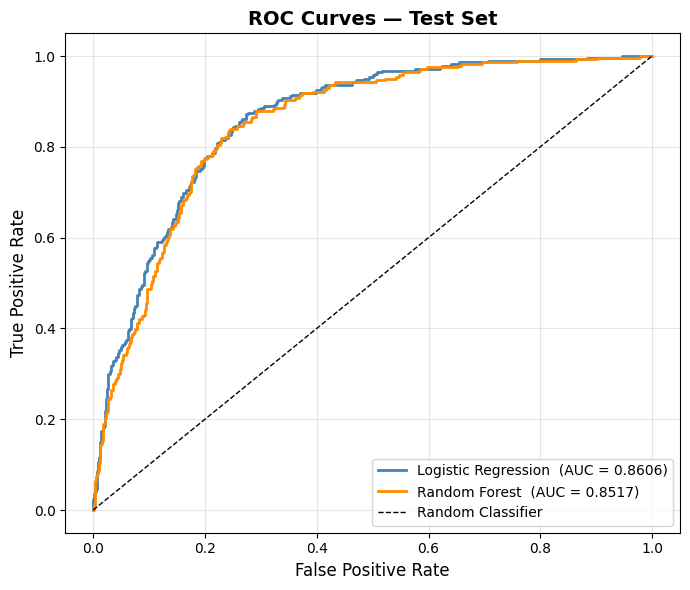

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models = {
    "Logistic Regression": best_lr_pipeline,
    "Random Forest":       best_rf_pipeline,
}

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["steelblue", "darkorange"]

for (name, pipeline), color in zip(models.items(), colors):
    y_prob = pipeline.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve((y_test == "Yes").astype(int), y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name}  (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Test Set", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

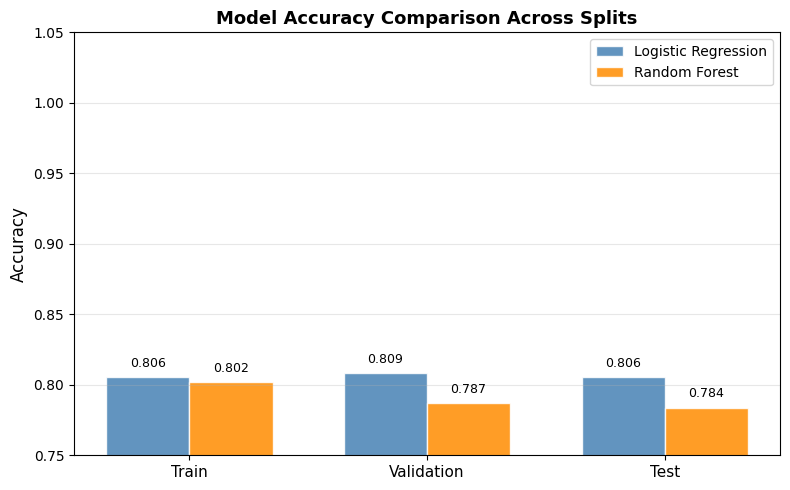

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": best_lr_pipeline,
    "Random Forest":       best_rf_pipeline,
}

splits = ["Train", "Validation", "Test"]
x_pos = np.arange(len(splits))
width = 0.35
bar_colors = ["steelblue", "darkorange"]

fig, ax = plt.subplots(figsize=(8, 5))
for i, (name, pipeline) in enumerate(models.items()):
    accuracies = [
        pipeline.score(x_training,   y_training),
        pipeline.score(x_validation, y_validation),
        pipeline.score(x_test,       y_test),
    ]
    bars = ax.bar(x_pos + i * width, accuracies, width,
                  label=name, color=bar_colors[i], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x_pos + width / 2)
ax.set_xticklabels(splits, fontsize=11)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0.75, 1.05)
ax.set_title("Model Accuracy Comparison Across Splits",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()